In [1]:
from __future__ import print_function
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
from scipy import stats
from IPython.display import display, HTML

# sklearn packages
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split

# pickle for model serialization
import pickle

# TensorFlow Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Reshape, LSTM, TimeDistributed,
    Conv1D, MaxPooling1D, ConvLSTM2D, BatchNormalization
)
from tensorflow.keras.utils import to_categorical

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Visualization settings
sns.set()
plt.style.use('ggplot')

# Display pandas floats with one decimal point
pd.options.display.float_format = '{:.1f}'.format

# Print versions for compatibility
print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)
print('Seaborn version:', sns.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)
print('XGBoost version:', XGBClassifier.__module__.split('.')[0])

print("Setup complete.")


TensorFlow version: 2.18.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Seaborn version: 0.13.2
Matplotlib version: 3.10.0
XGBoost version: xgboost
Setup complete.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Labels using throughout the dataset and modeling
labels = ['Downstairs','Jogging','Sitting','Standing','Upstairs','Walking']

Missing values:
            0
user-id    0
activity   0
timestamp  0
x-axis     0
y-axis     0
z-axis     1


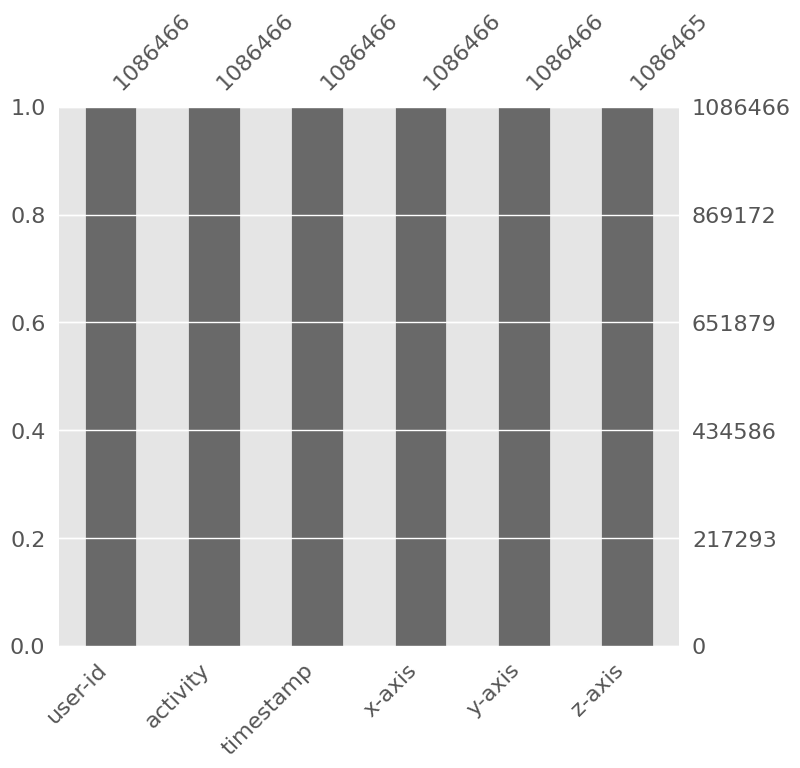

In [4]:
def read_data(file_path):
    col_names = ['user-id', 'activity', 'timestamp', 'x-axis', 'y-axis', 'z-axis']

    # Read the CSV file while skipping malformed lines
    df = pd.read_csv(
        file_path,
        header=None,
        names=col_names,
        on_bad_lines='skip',  # Skip lines with errors
    )

    # Remove ";" in the last column and convert the column to float
    df['z-axis'] = df['z-axis'].str.replace(';', '', regex=False)
    df['z-axis'] = pd.to_numeric(df['z-axis'], errors='coerce')

    # Check missing values
    print('Missing values:\n', pd.DataFrame(df.isnull().sum()))
    msno.bar(df, figsize=(8, 7))

    # Drop rows with NaN values
    df.dropna(axis=0, how='any', inplace=True)

    return df

# Load data set containing all the data from the CSV
file_path = '/content/drive/MyDrive/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt'
df = read_data(file_path)


In [5]:
# Describe the data
print('Data Shape:', df.shape)
df.head(10)

Data Shape: (1086465, 6)


,user-id,activity,timestamp,x-axis,y-axis,z-axis
0,33,Jogging,49105962326000,-0.7,12.7,0.5
1,33,Jogging,49106062271000,5.0,11.3,1.0
2,33,Jogging,49106112167000,4.9,10.9,-0.1
3,33,Jogging,49106222305000,-0.6,18.5,3.0
4,33,Jogging,49106332290000,-1.2,12.1,7.2
5,33,Jogging,49106442306000,1.4,-2.5,-6.5
6,33,Jogging,49106542312000,-0.6,10.6,5.7
7,33,Jogging,49106652389000,-0.5,13.9,7.1
8,33,Jogging,49106762313000,-8.4,11.4,5.1
9,33,Jogging,49106872299000,1.0,1.4,1.6


In [6]:
# Number of users and unique id:
print('Total_id:', len(df['user-id'].unique()))
df['user-id'].unique()

Total_id: 36


array([33, 17, 20, 29, 13, 15,  6, 27, 36, 18, 32, 35, 11, 16,  5, 10, 28,
       26, 14, 24, 12, 23,  4, 30, 34,  8, 31, 21,  3, 22,  1,  9, 25,  2,
        7, 19])

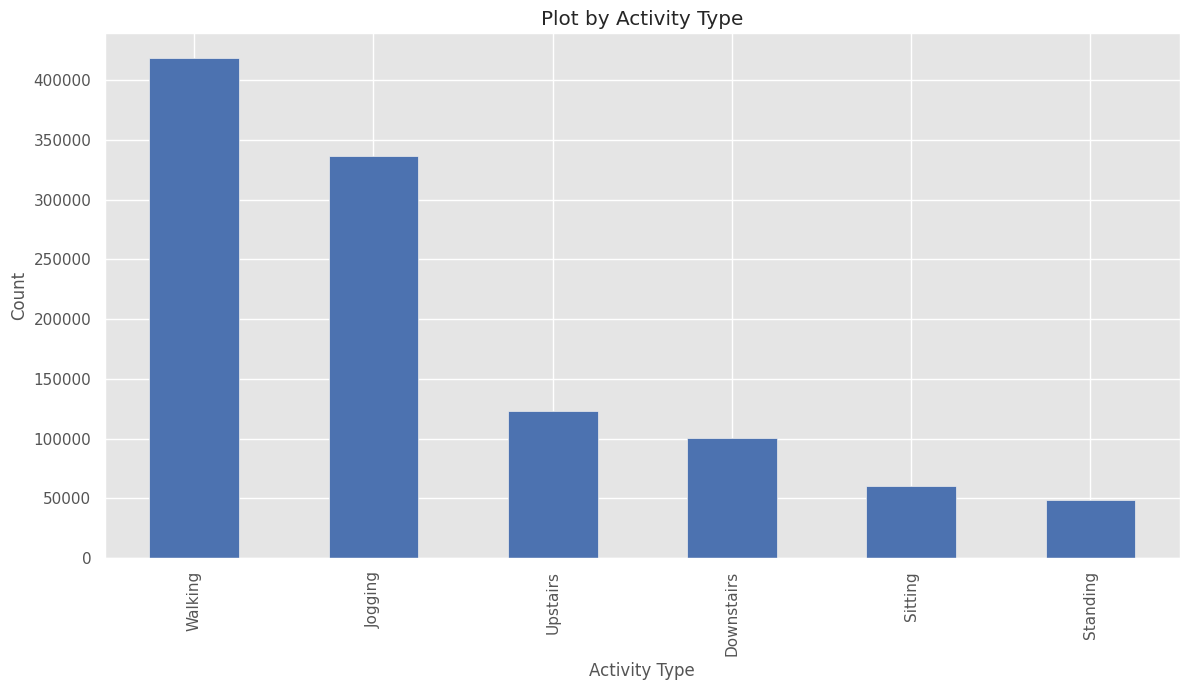

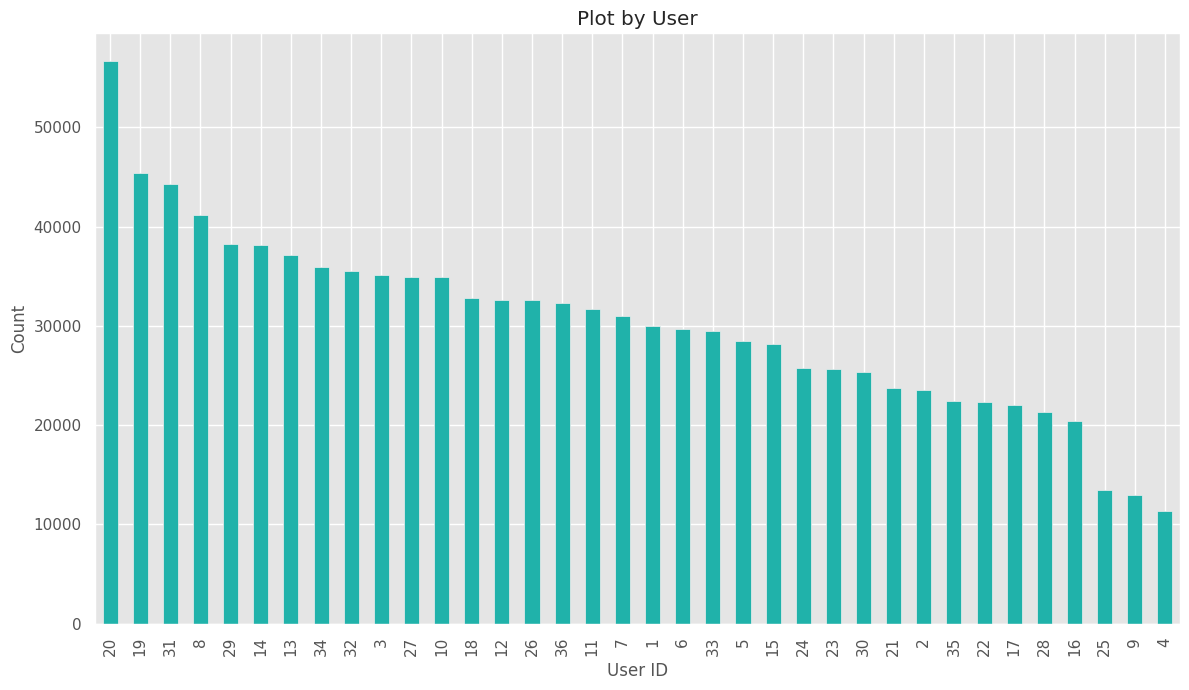

In [ ]:
# Show how many training examples exist for each of the six activities
fig, ax = plt.subplots(figsize=(12, 7))
df['activity'].value_counts().plot(kind='bar', ax=ax, title='Plot by Activity Type', color='b')
ax.set_ylabel('Count')
ax.set_xlabel('Activity Type')
plt.tight_layout()
plt.show()

# Training by records (users)
fig, ax = plt.subplots(figsize=(12, 7))
df['user-id'].value_counts().plot(kind='bar', ax=ax, title='Plot by User', color='lightseagreen')
ax.set_ylabel('Count')
ax.set_xlabel('User ID')
plt.tight_layout()
plt.show()


In [7]:
# Activity by users - Cross-tabulation with 'Total' for both rows and columns
activity_by_user = pd.crosstab(df['user-id'], df['activity'], margins=True, margins_name='Total').sort_values(by='Total', ascending=False)

# Display the result
print(activity_by_user)


activity  Downstairs  Jogging  Sitting  Standing  Upstairs  Walking    Total
user-id                                                                     
Total         100425   336445    59939     48394    122869   418393  1086465
20              4673    12948    15644      5389      4844    13134    56632
19              2614    16201     2534      2132      4280    17622    45383
31              3892    14075     2148      2612      4679    16876    44282
8               3346    10313     2699      3269      4453    17108    41188
29              4329    12788     2319      1603      4786    12420    38245
14              2875    13279        0         0      8179    13859    38192
13              4240    12329     1179      1659      4638    13047    37092
34              2856    12869     1575      1349      3921    13377    35947
32              2343    12245     3059      1669      3814    12376    35506
3               3326    11018     1609      2824      3411    12973    35161

In [8]:
# Grouping the dataset between the 170,000th and 270,000th record by 'activity' and counting the occurrences of each activity
activity_counts = df[170000:270000].groupby('activity').count()

# Display the counts for each activity in the range
print(activity_counts)


            user-id  timestamp  x-axis  y-axis  z-axis
activity                                              
Downstairs     9060       9060    9060    9060    9060
Jogging       35100      35100   35100   35100   35100
Sitting        4599       4599    4599    4599    4599
Standing       3555       3555    3555    3555    3555
Upstairs      10352      10352   10352   10352   10352
Walking       37334      37334   37334   37334   37334


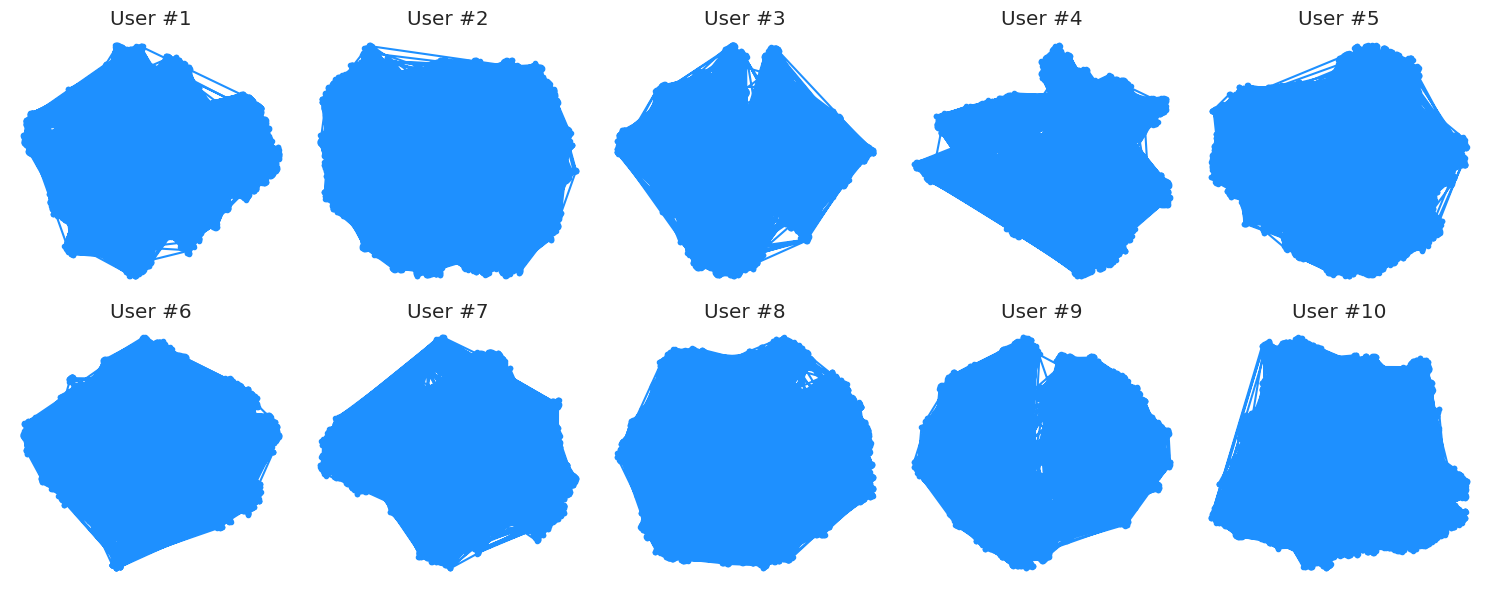

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(15,6))

for person in range(0, 10):
    # Get data
    single_person = df[(df['activity']=='Walking') & (df['user-id']==(person+1))].drop(['user-id', 'activity','timestamp'], axis=1)

    # Transform data
    tsne = TSNE(random_state=911)
    tsne_transformed_person = tsne.fit_transform(single_person)

    # Create plot
    ax[person//5][person%5].plot(tsne_transformed_person[:,0], tsne_transformed_person[:,1], '.-', color='dodgerblue')
    ax[person//5][person%5].set_title('User #{}'.format(person+1))
    ax[person//5][person%5].axis('off')

plt.tight_layout()
plt.show()

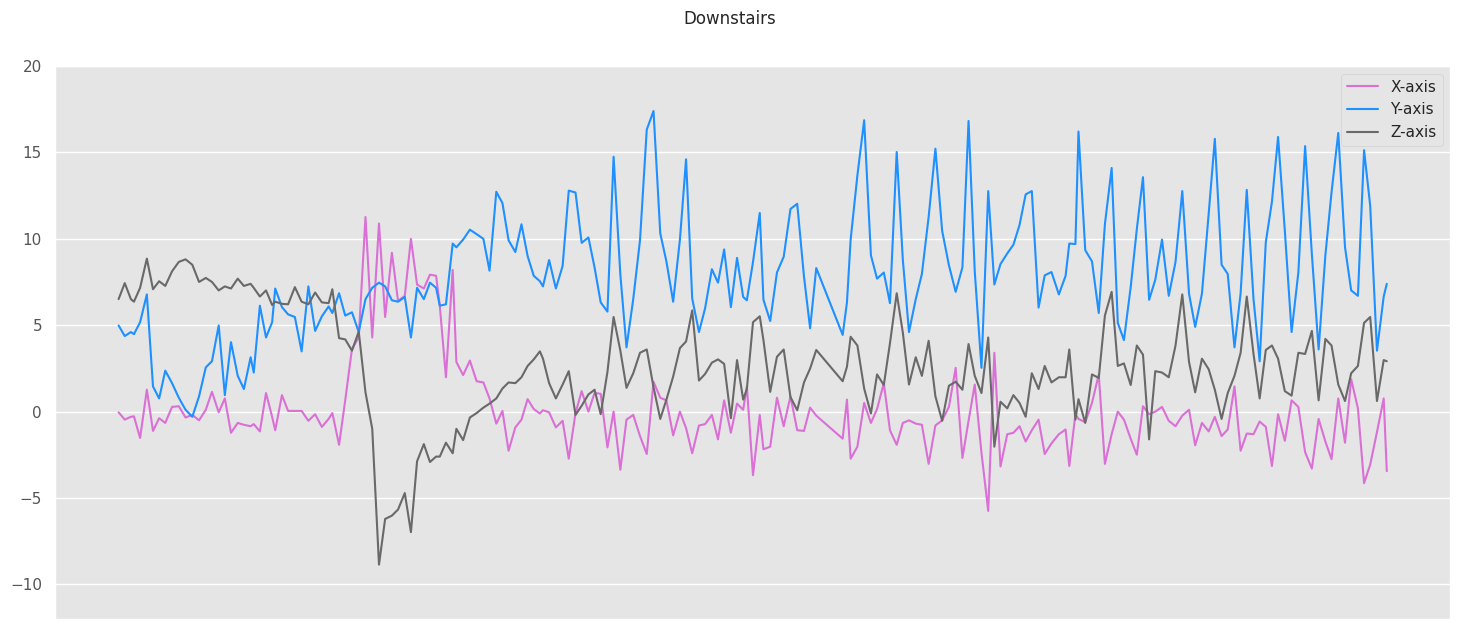

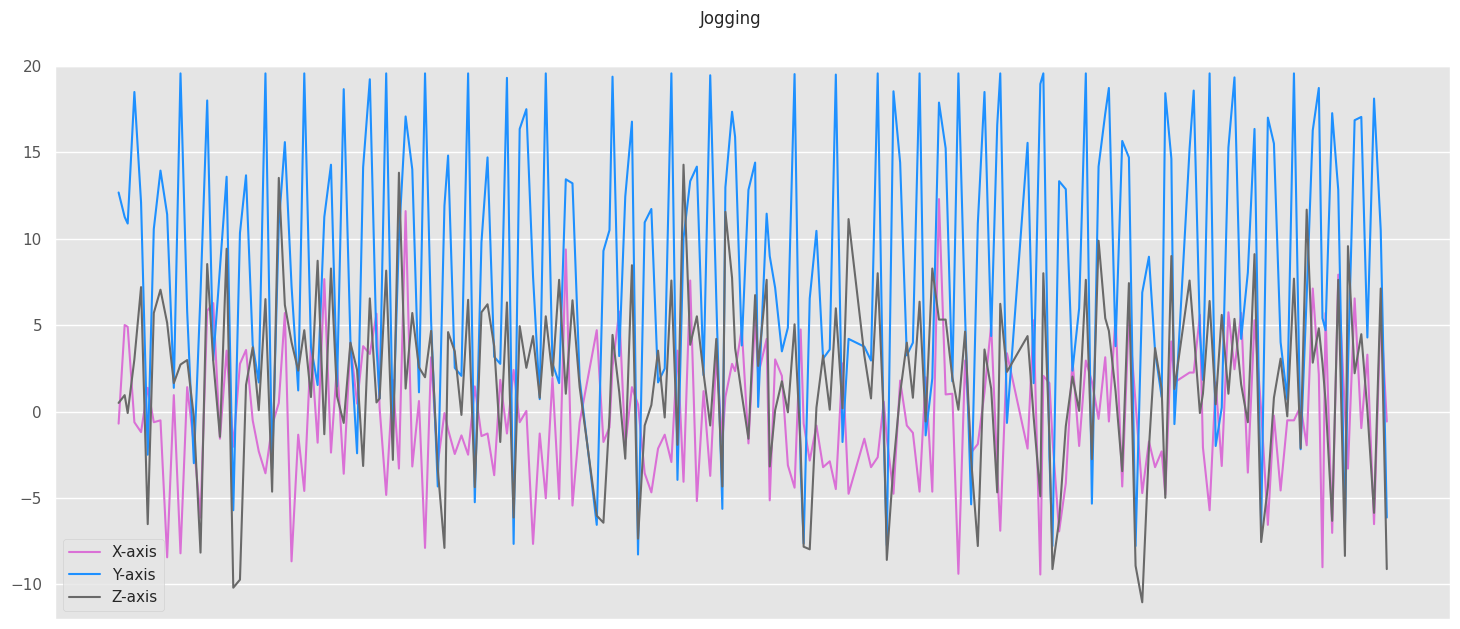

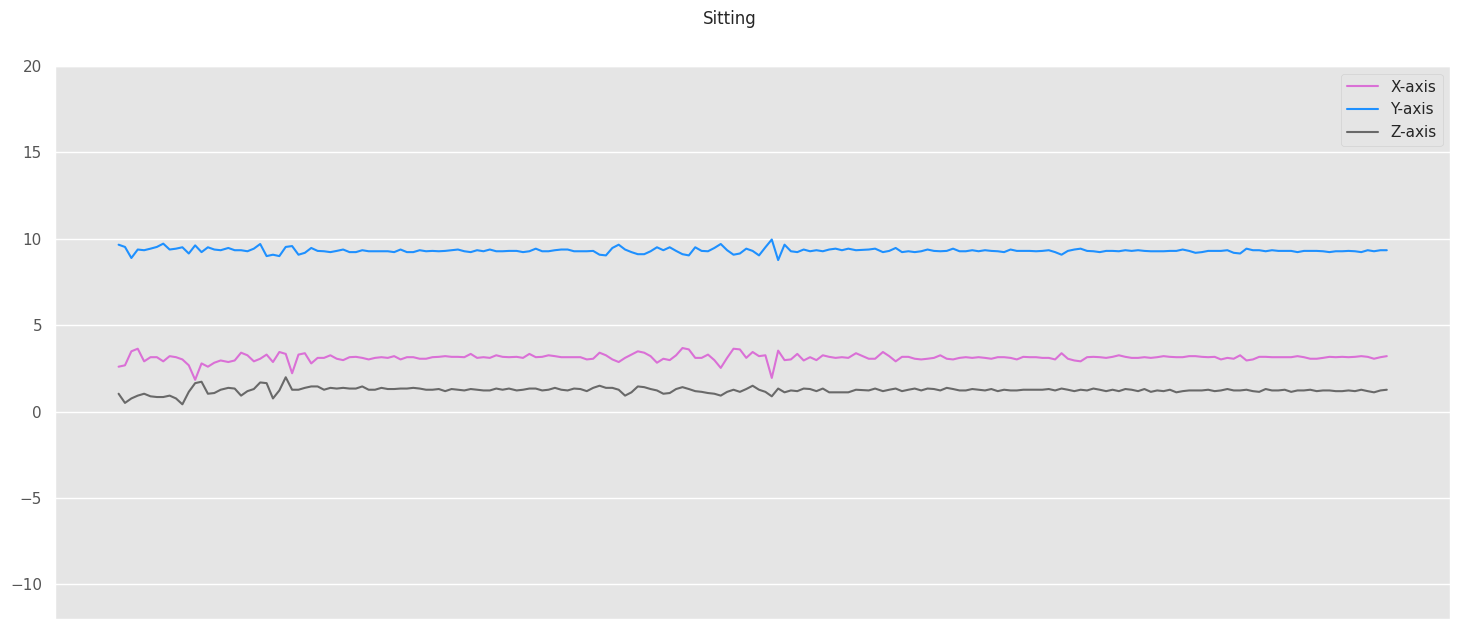

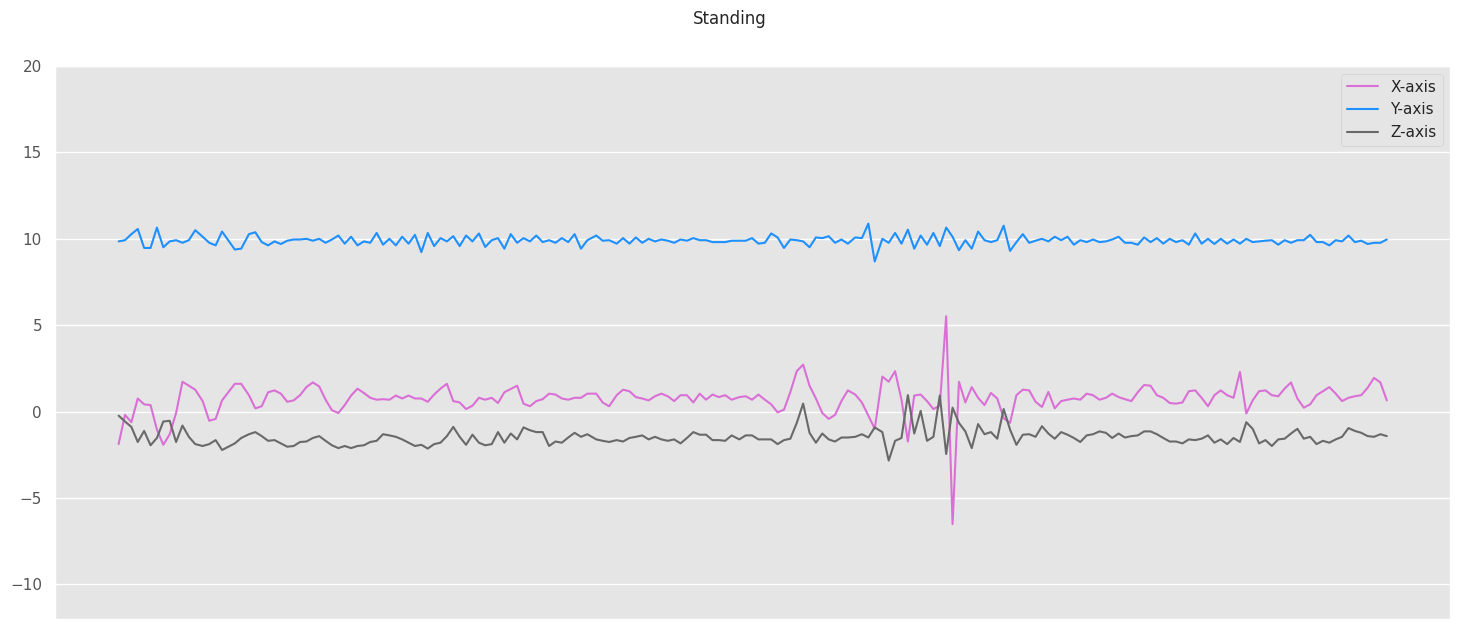

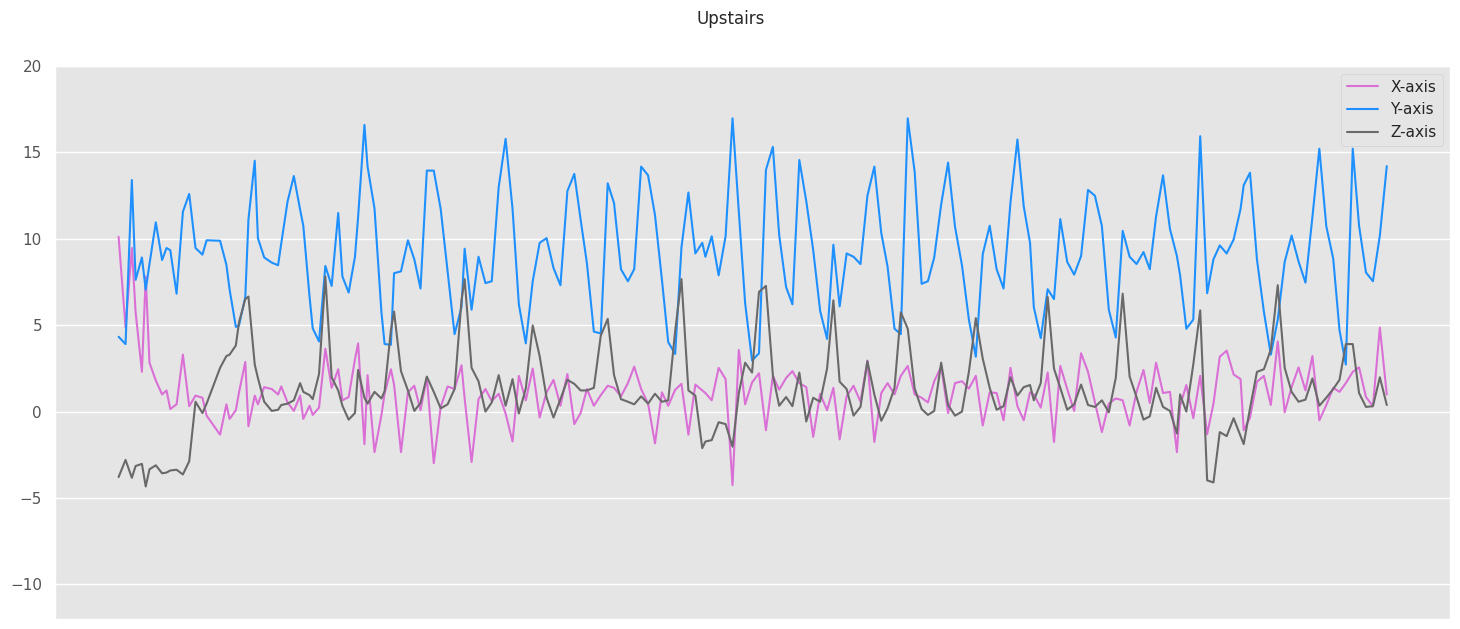

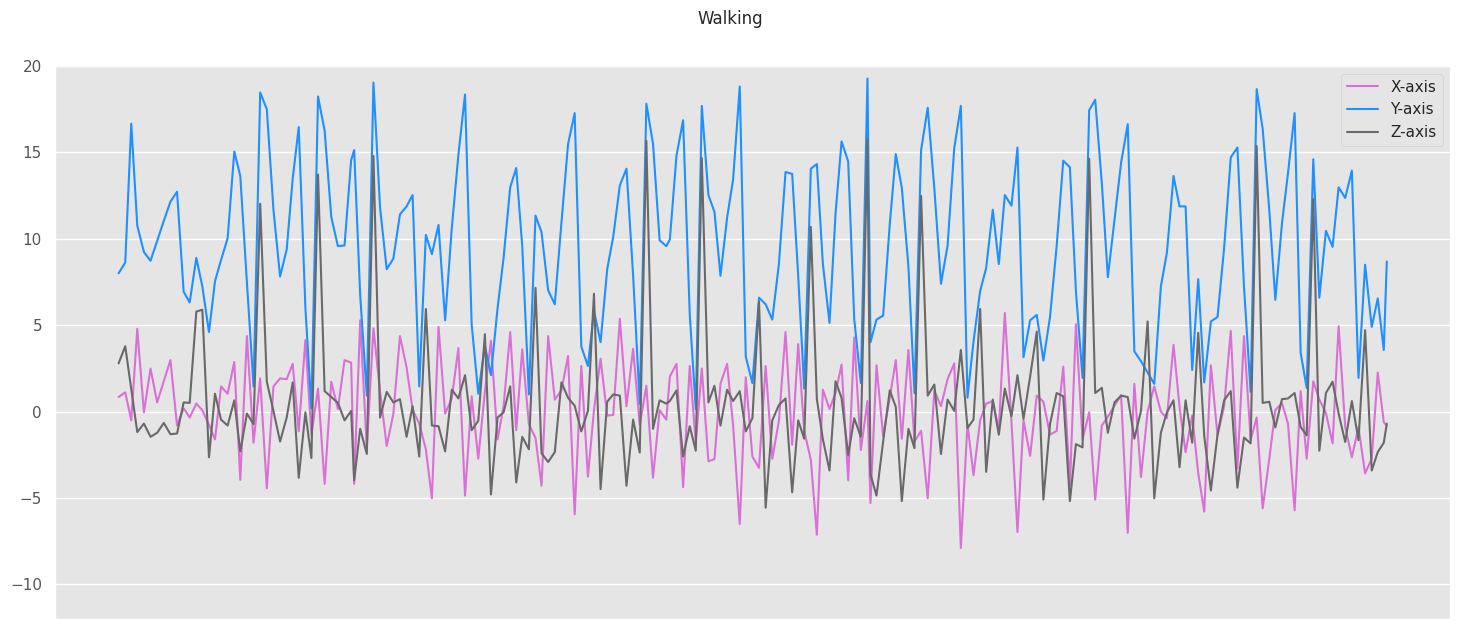

In [ ]:
def plot_activity(activity, data):

    fig, ax = plt.subplots(figsize=(18, 7))
    plt.plot( data['timestamp'], data['x-axis'], color='orchid', linewidth=1.5, label="X-axis")
    plt.plot( data['timestamp'], data['y-axis'], color='dodgerblue', linewidth=1.5,  label="Y-axis")
    plt.plot( data['timestamp'], data['z-axis'], color='dimgrey', linewidth=1.5, label="Z-axis")
    plt.subplots_adjust(hspace=0.2)
    plt.subplots_adjust(top=0.90)
    plt.suptitle(activity)
    plt.legend()
    plt.ylim(-12 , 20)
    plt.grid(True)
    plt.xticks([])
    plt.show()

for activity in np.unique(df['activity']):
    subset = df[df['activity'] == activity][:200]
    plot_activity(activity, subset)

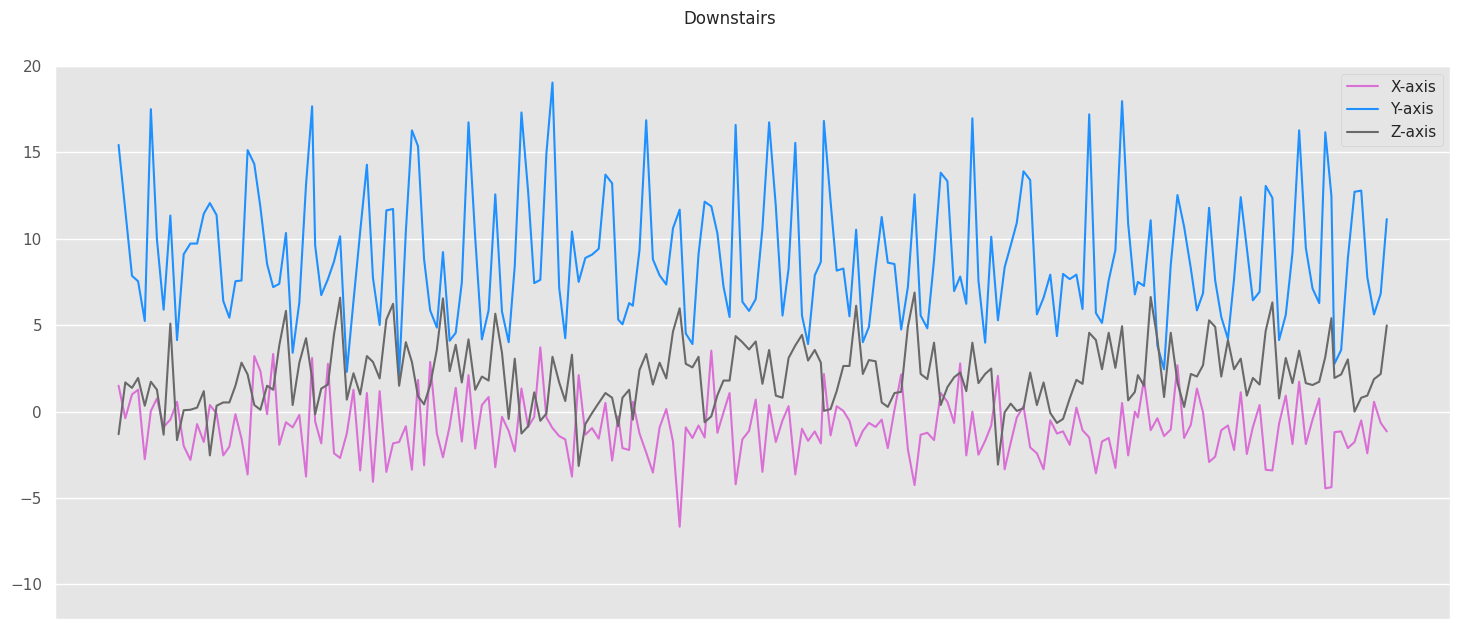

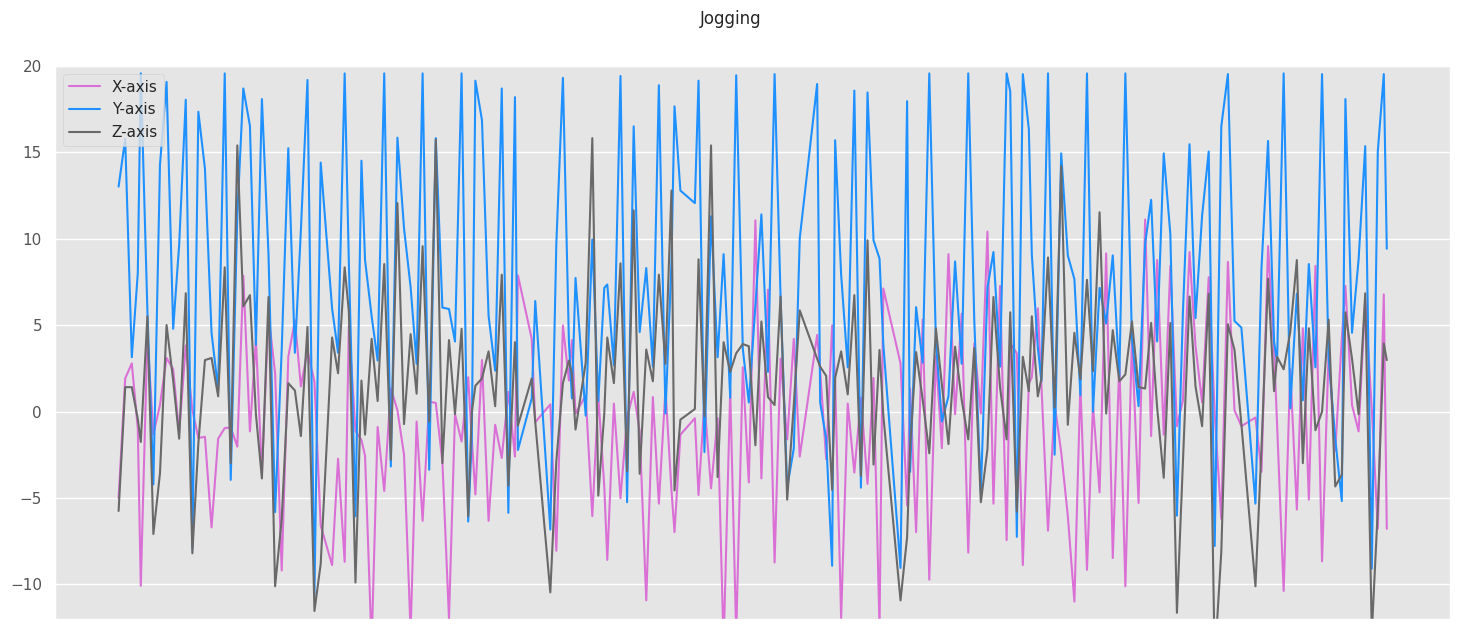

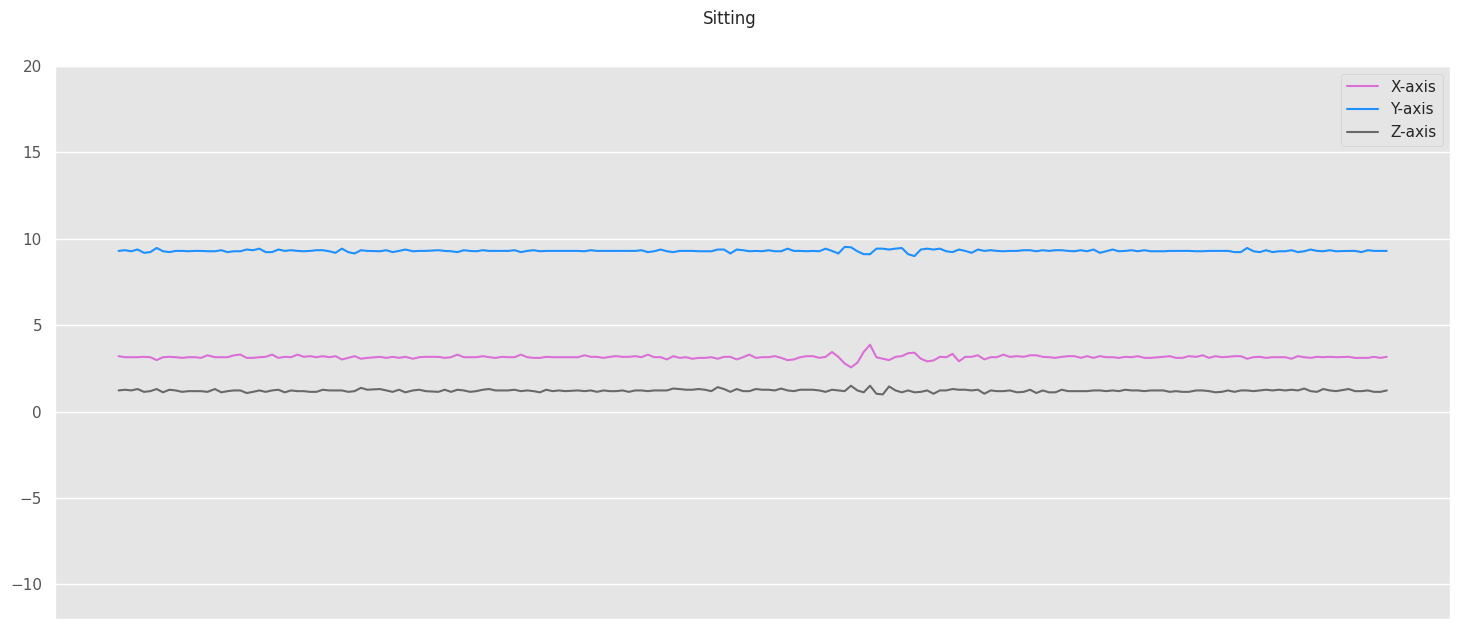

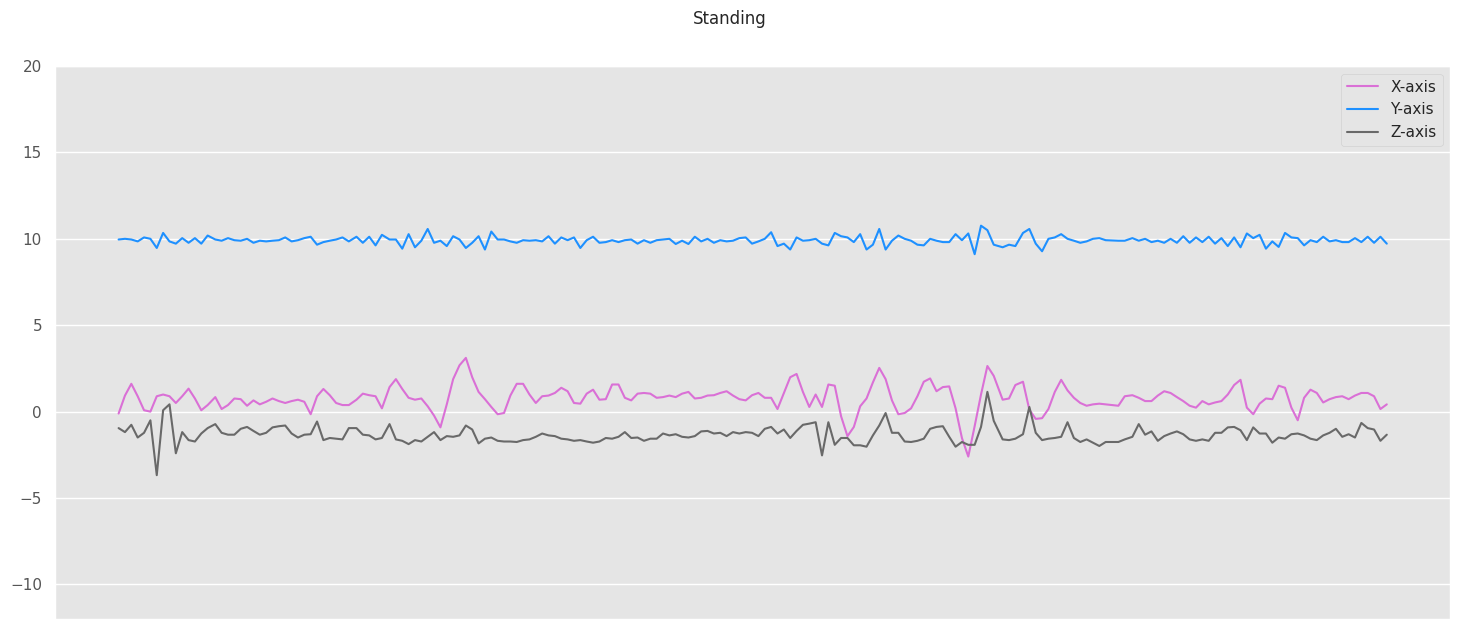

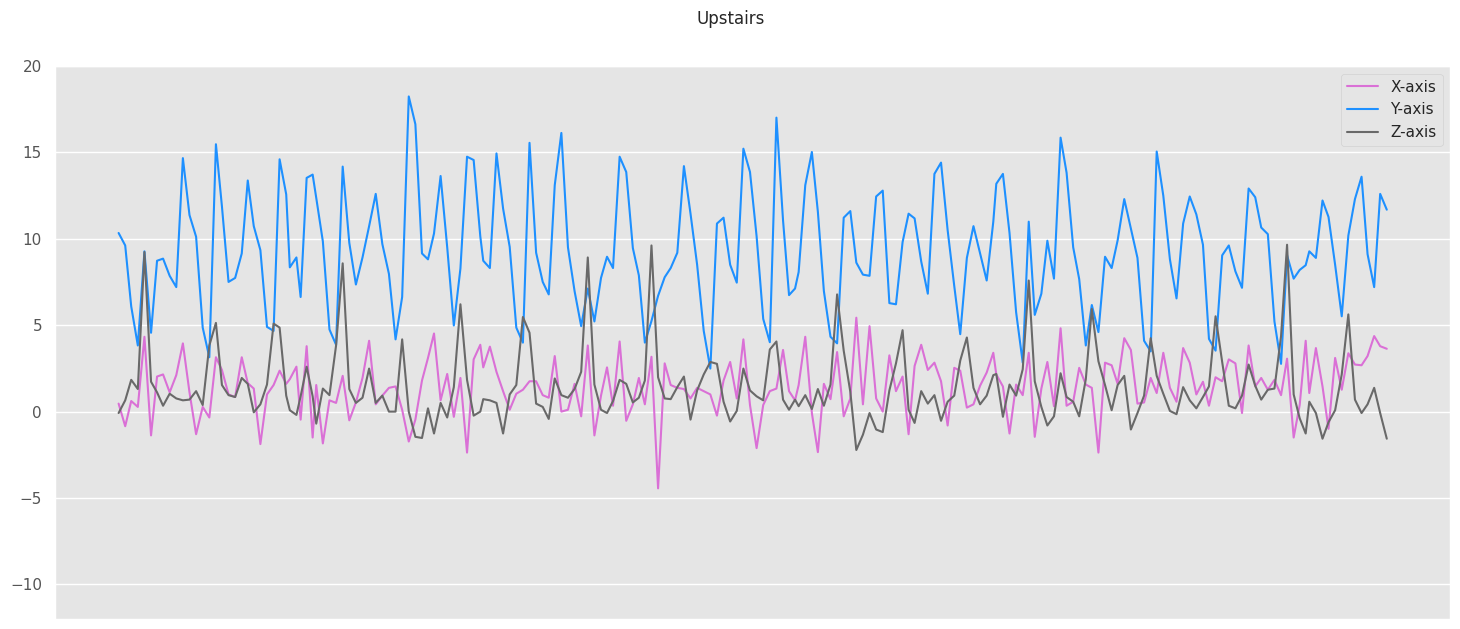

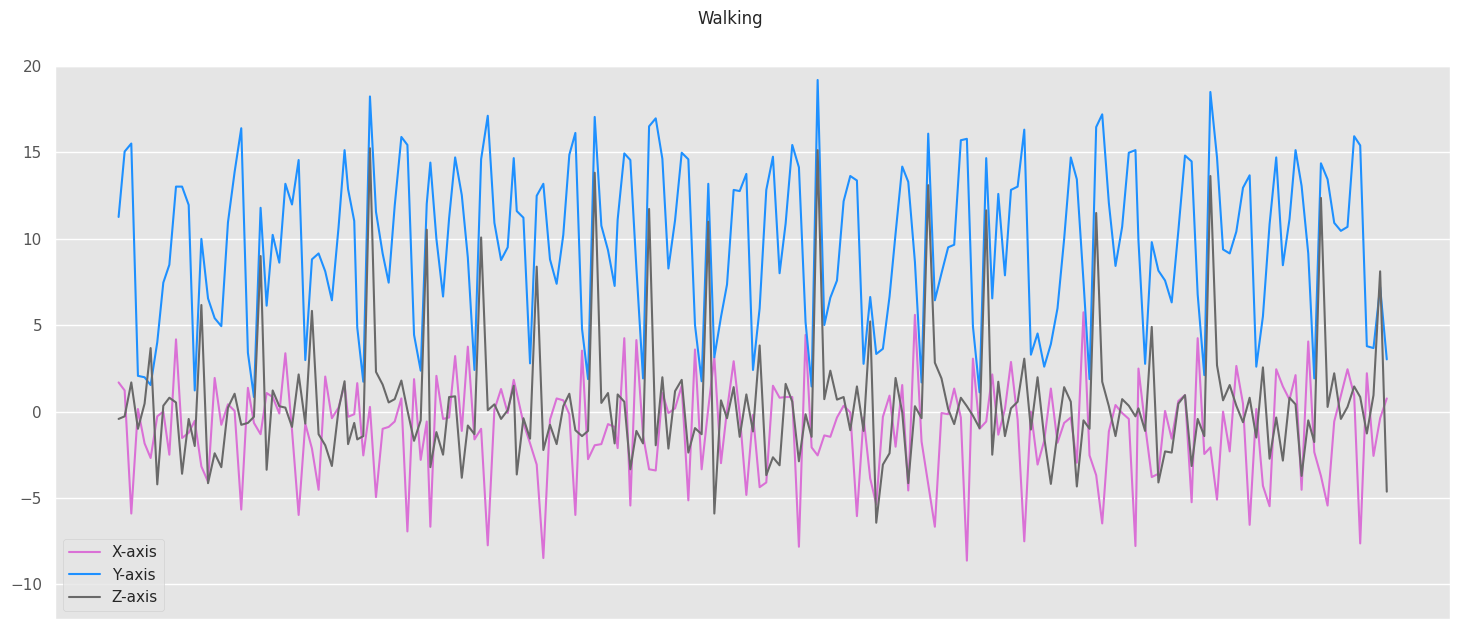

In [ ]:
for activity in np.unique(df['activity']):
    subset = df[df['activity'] == activity][200:400]
    plot_activity(activity, subset)

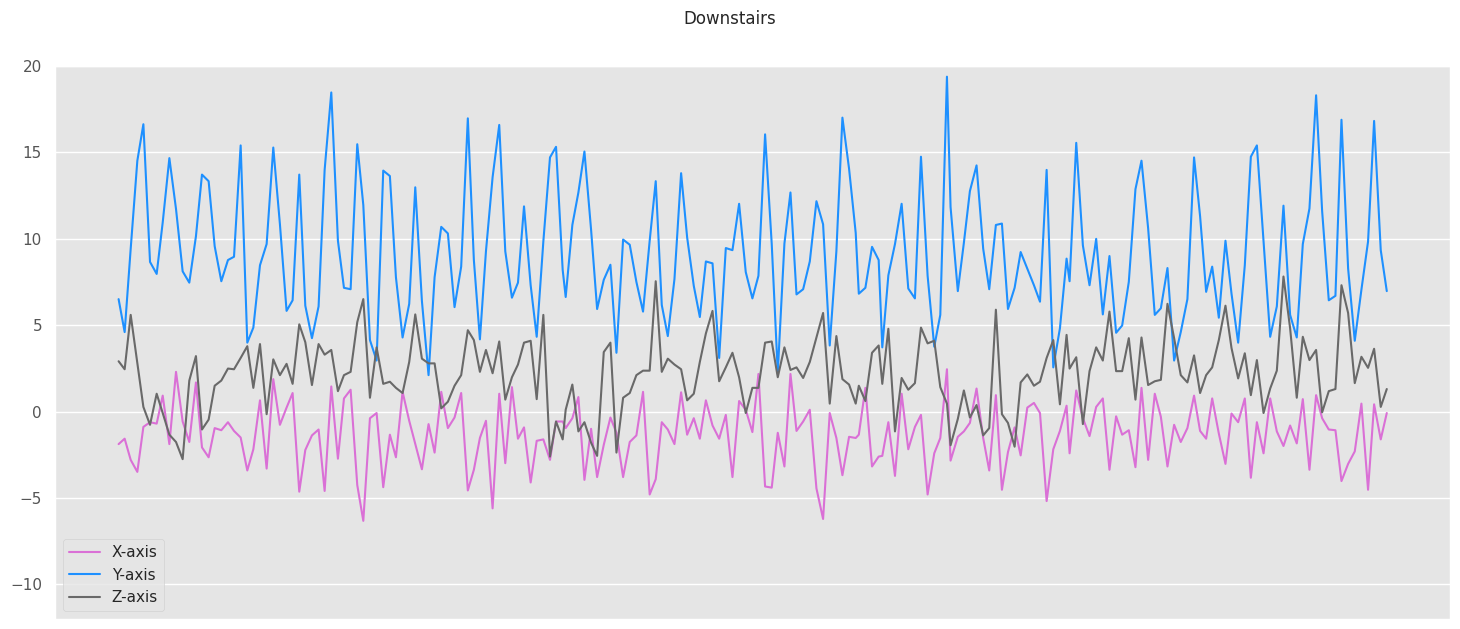

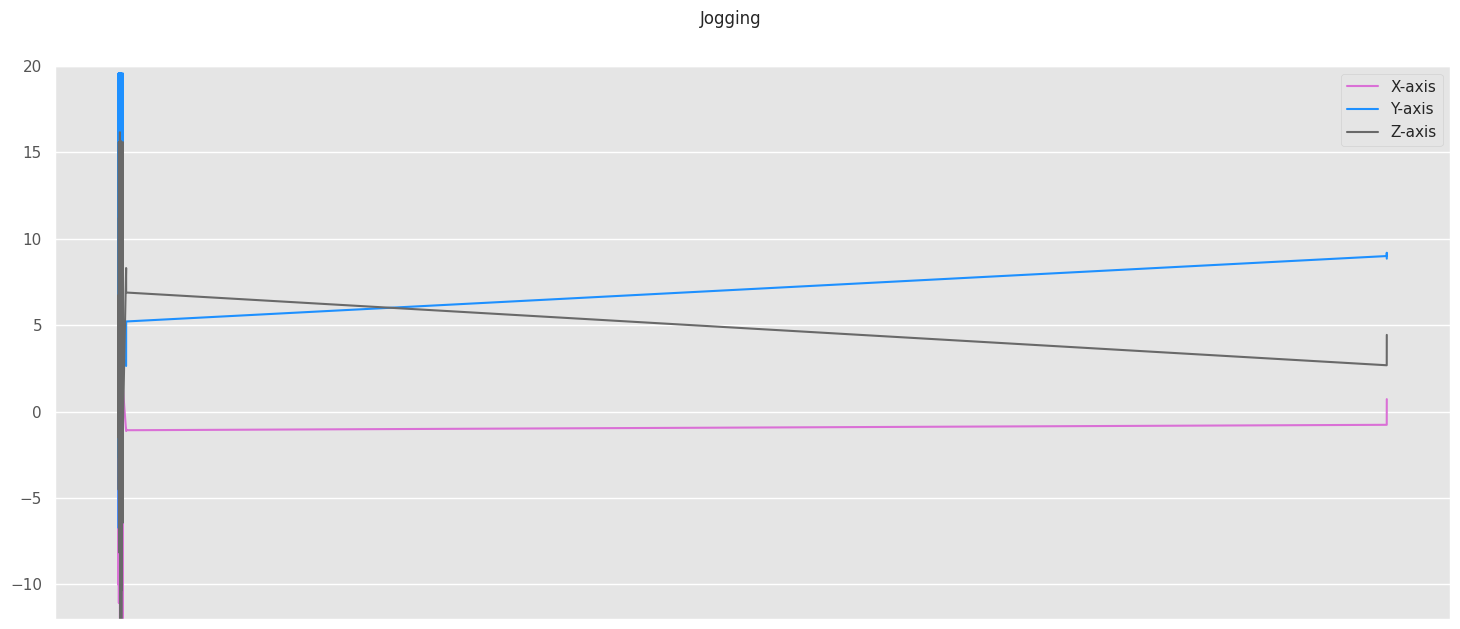

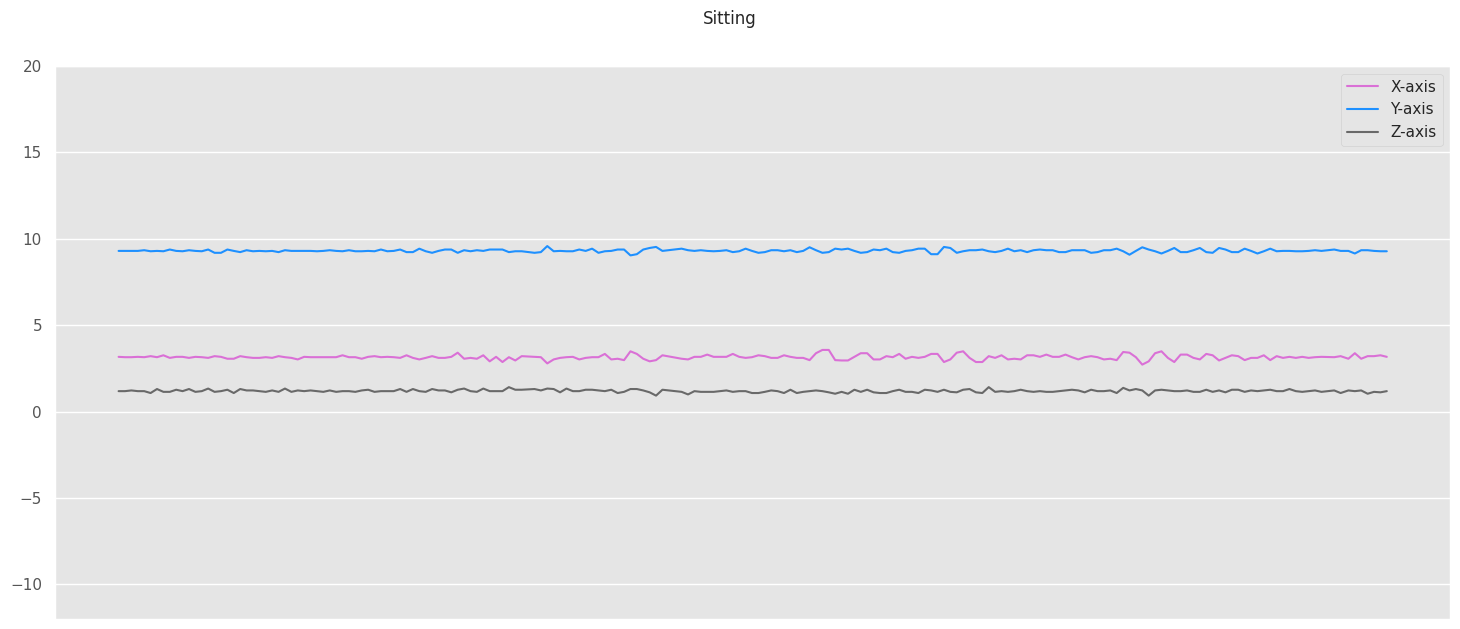

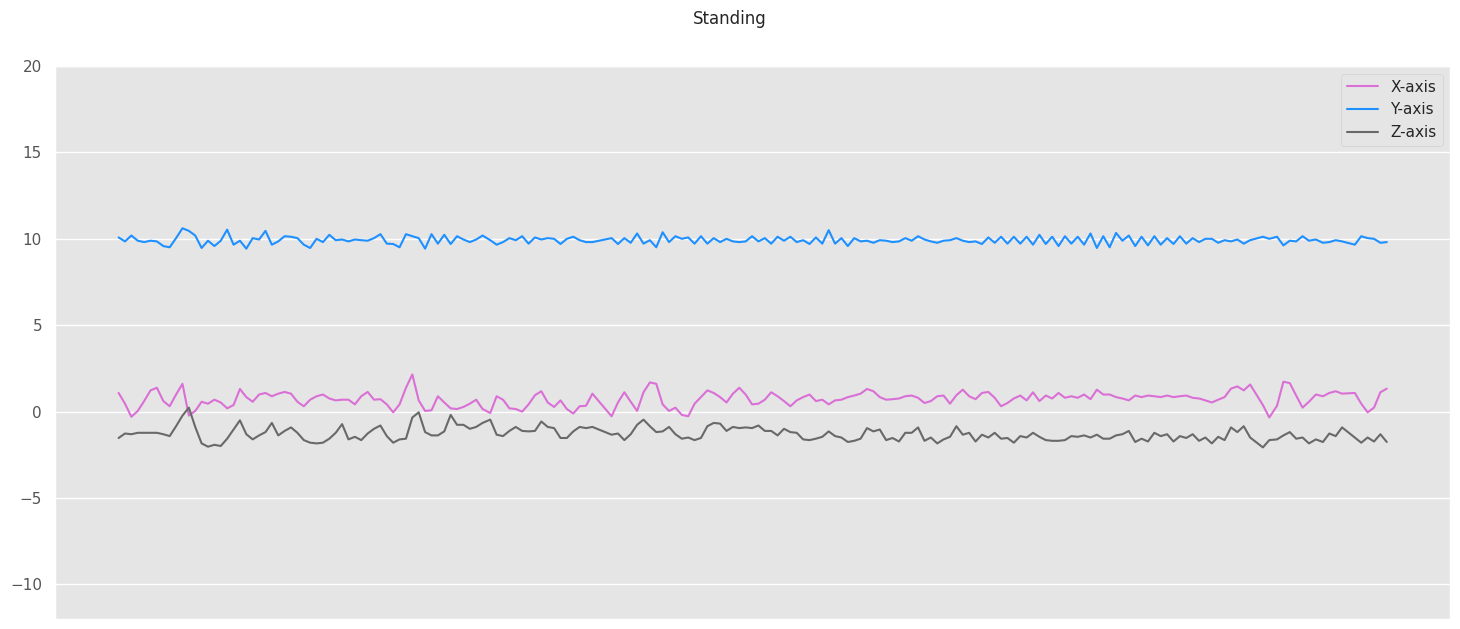

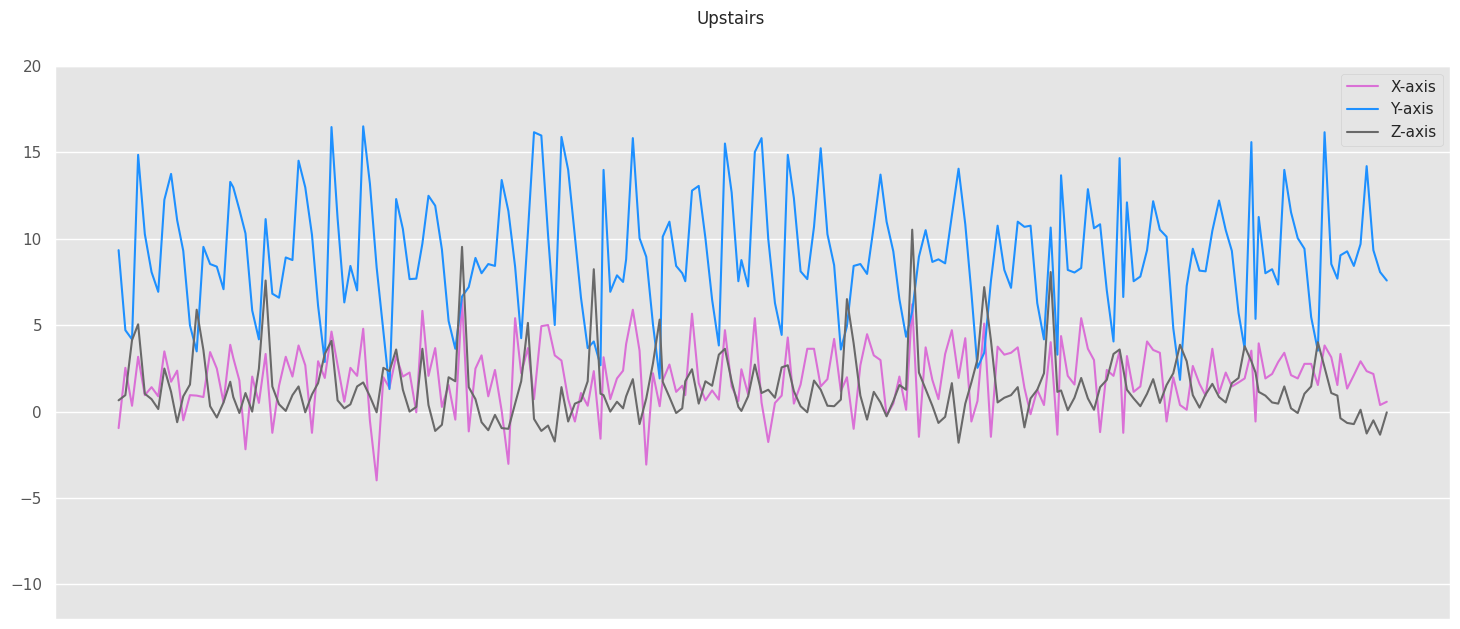

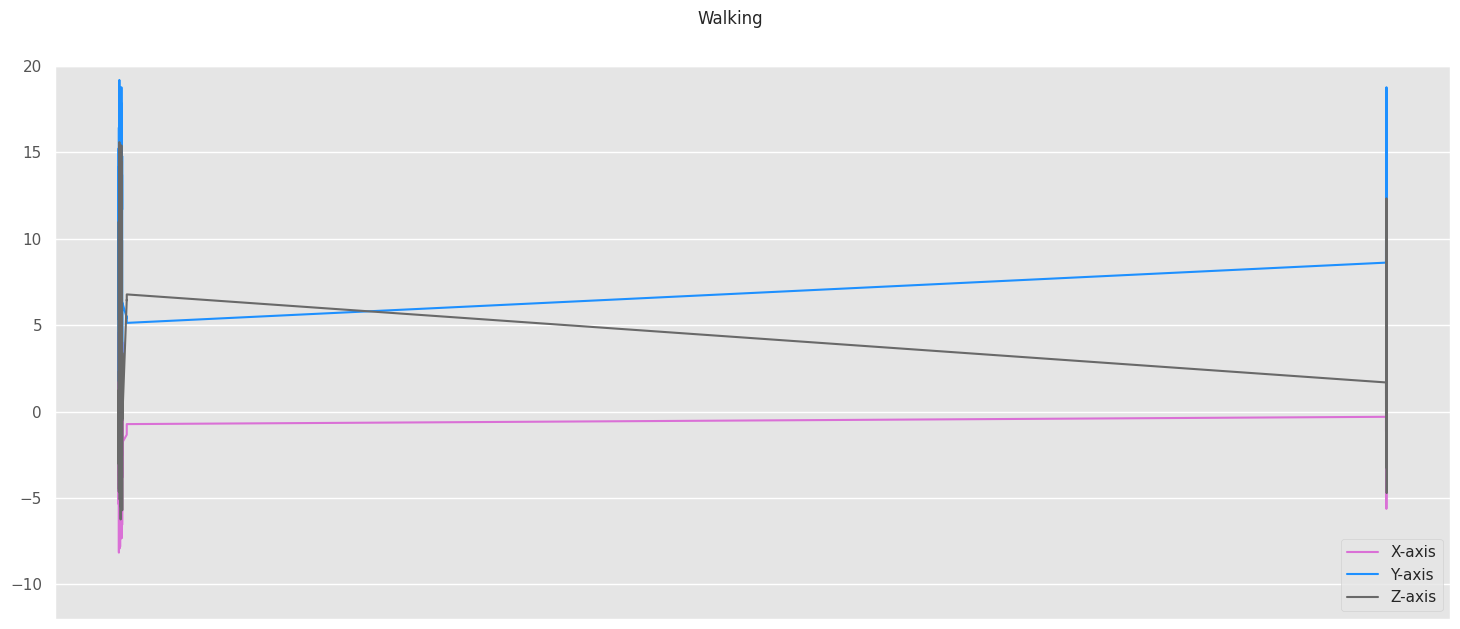

In [ ]:
for activity in np.unique(df['activity']):
    subset = df[df['activity'] == activity][400:600]
    plot_activity(activity, subset)

In [9]:
# Filter timestamp = 0
df[(df['timestamp']== 0)]

,user-id,activity,timestamp,x-axis,y-axis,z-axis
14398,20,Walking,0,0.0,0.0,0.0
14399,20,Walking,0,0.0,0.0,0.0
14643,20,Walking,0,0.0,0.0,0.0
14644,20,Walking,0,0.0,0.0,0.0
14645,20,Walking,0,0.0,0.0,0.0
...,...,...,...,...,...,...
870639,3,Walking,0,0.0,0.0,0.0
870640,3,Walking,0,0.0,0.0,0.0
926475,22,Downstairs,0,0.0,0.0,0.0
926476,22,Downstairs,0,0.0,0.0,0.0


In [10]:
# Any data with timestamp = 0 also means x, y and z axis = 0 ( same data.shape)
df[(df['x-axis']== 0) & (df['y-axis']== 0)]

,user-id,activity,timestamp,x-axis,y-axis,z-axis
14398,20,Walking,0,0.0,0.0,0.0
14399,20,Walking,0,0.0,0.0,0.0
14643,20,Walking,0,0.0,0.0,0.0
14644,20,Walking,0,0.0,0.0,0.0
14645,20,Walking,0,0.0,0.0,0.0
...,...,...,...,...,...,...
870639,3,Walking,0,0.0,0.0,0.0
870640,3,Walking,0,0.0,0.0,0.0
926475,22,Downstairs,0,0.0,0.0,0.0
926476,22,Downstairs,0,0.0,0.0,0.0


In [11]:
# Total number of activity
df.groupby(by = 'activity').count().sort_values('user-id', ascending = False)

,user-id,timestamp,x-axis,y-axis,z-axis
activity,,,,,
Walking,418393,418393,418393,418393,418393
Jogging,336445,336445,336445,336445,336445
Upstairs,122869,122869,122869,122869,122869
Downstairs,100425,100425,100425,100425,100425
Sitting,59939,59939,59939,59939,59939
Standing,48394,48394,48394,48394,48394


In [12]:
# Total number of activity have 0 for all axes.
df[(df['timestamp']== 0)].groupby(by = 'activity').count()

,user-id,timestamp,x-axis,y-axis,z-axis
activity,,,,,
Downstairs,233,233,233,233,233
Jogging,11845,11845,11845,11845,11845
Standing,1,1,1,1,1
Upstairs,271,271,271,271,271
Walking,492,492,492,492,492


In [13]:
# Take user-id 20 as an example. When did timestamp = 0 happen?
df[(df['user-id']== 20)][30:50]

,user-id,activity,timestamp,x-axis,y-axis,z-axis
14383,20,Walking,325712230000,7.7,13.3,1.1
14384,20,Walking,325762340000,9.7,9.1,3.0
14385,20,Walking,325812694000,3.5,15.2,-7.9
14386,20,Walking,325862376000,2.9,17.0,-1.6
14387,20,Walking,325912212000,6.9,9.3,-1.6
14388,20,Walking,325962321000,3.3,4.4,-3.6
14389,20,Walking,326012279000,-0.8,4.8,-1.5
14390,20,Walking,326062297000,-1.7,3.8,-1.7
14391,20,Walking,326112224000,1.4,4.1,1.2
14392,20,Walking,326162273000,10.3,7.8,6.4


In [14]:
# Import preprocessing
from sklearn import preprocessing

# Define column name of the label vector
label = 'ActivityEncoded'

# Transform the labels from String to Integer via LabelEncoder
le = preprocessing.LabelEncoder()

# Add a new column to the existing DataFrame with the encoded values
df[label] = le.fit_transform(df['activity'].values.ravel())


In [15]:
df.head()

,user-id,activity,timestamp,x-axis,y-axis,z-axis,ActivityEncoded
0,33,Jogging,49105962326000,-0.7,12.7,0.5,1
1,33,Jogging,49106062271000,5.0,11.3,1.0,1
2,33,Jogging,49106112167000,4.9,10.9,-0.1,1
3,33,Jogging,49106222305000,-0.6,18.5,3.0,1
4,33,Jogging,49106332290000,-1.2,12.1,7.2,1


In [16]:
df.tail(10)

,user-id,activity,timestamp,x-axis,y-axis,z-axis,ActivityEncoded
1086456,19,Sitting,131623091524000,8.5,-1.3,2.5,2
1086457,19,Sitting,131623131471000,8.7,-1.3,2.4,2
1086458,19,Sitting,131623172578000,8.8,-1.3,2.2,2
1086459,19,Sitting,131623251466000,9.1,-1.4,1.9,2
1086460,19,Sitting,131623291475000,9.0,-1.5,1.8,2
1086461,19,Sitting,131623331483000,9.0,-1.6,1.7,2
1086462,19,Sitting,131623371431000,9.0,-1.5,1.7,2
1086463,19,Sitting,131623411592000,9.1,-1.4,1.7,2
1086464,19,Sitting,131623491487000,9.0,-1.5,1.7,2
1086465,19,Sitting,131623531465000,8.9,-1.3,1.6,2


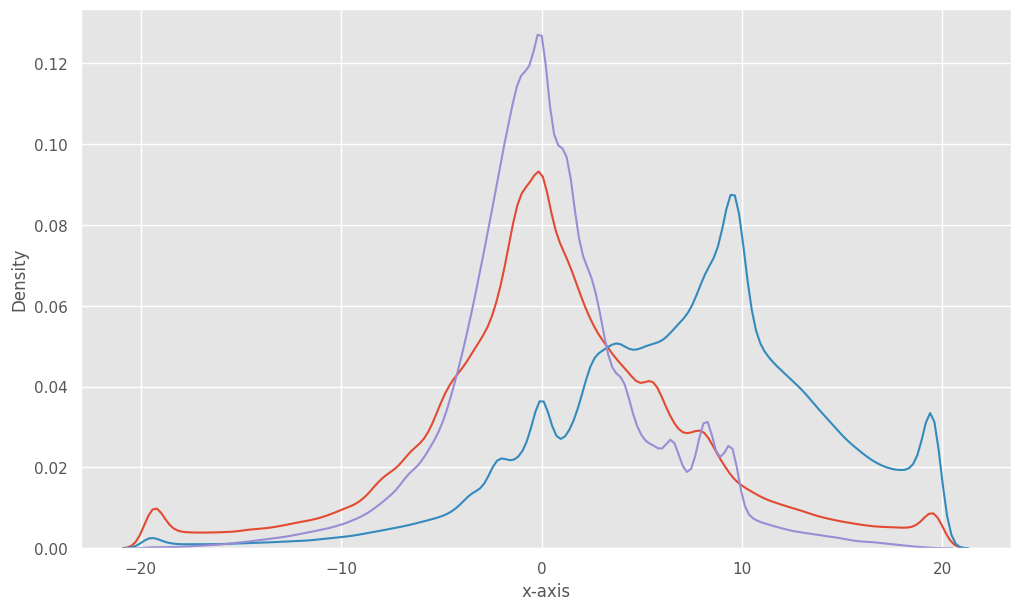

In [ ]:
fig= plt.figure(figsize=(12,7))
col = ['x-axis','y-axis','z-axis']
for i in col:
    sns.kdeplot(df[i])
plt.show()

## **MODELING**

In [55]:
# 10s interval for 200 training example
time_steps = 200
# 20 samples/second
step = 20
n_features = 3

In [18]:
import numpy as np

def create_segments_and_labels(df, time_steps, step):
    # x, y, z acceleration as features
    n_features = 3
    # Each generated sequence contains 200 training examples
    segments = []
    labels = []

    for i in range(0, len(df) - time_steps, step):
        xs = df['x-axis'].values[i: i + time_steps]
        ys = df['y-axis'].values[i: i + time_steps]
        zs = df['z-axis'].values[i: i + time_steps]
        # Retrieve the most frequently used label in each segment using np.unique
        label = np.unique(df['activity'][i: i + time_steps])[0]  # Pick the most frequent label
        segments.append([xs, ys, zs])
        labels.append(label)

    # Bring the segments into a better shape
    reshaped_segments = np.asarray(segments, dtype=np.float32).reshape(-1, time_steps, n_features)

    return reshaped_segments, labels

# Now use the function with time_steps and step defined
time_steps = 200  # Define appropriate time_steps
step = 20  # Define appropriate step
reshaped_segments, labels = create_segments_and_labels(df, time_steps, step)

# Check the shape of reshaped_segments
print(reshaped_segments.shape)

# Check labels
print(labels[1])


(54314, 200, 3)
Jogging


In [19]:
from sklearn.model_selection import train_test_split
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(reshaped_segments, labels, test_size=0.25, stratify=labels, random_state=911)

In [20]:
print(X_train_res.shape, len(y_train_res))
print(X_test_res.shape, len(y_test_res))

(40735, 200, 3) 40735
(13579, 200, 3) 13579


In [21]:
stratify = {
    'total': pd.Series(labels),
    'train': pd.Series(y_train_res),
    'test': pd.Series(y_test_res)
}

pd.DataFrame(stratify).apply(pd.value_counts).apply(lambda col: col/col.sum()*100)

,total,train,test
Walking,37.5,37.5,37.5
Jogging,31.8,31.8,31.8
Downstairs,11.3,11.3,11.3
Upstairs,9.4,9.4,9.4
Sitting,5.7,5.7,5.7
Standing,4.3,4.3,4.3


In [22]:
# For data augmentation
X_train_aug = X_train_res
X_test_aug = X_test_res
y_train_aug = y_train_res
y_test_aug = y_test_res

In [23]:
# Enconding y label
y_train_res =np.asarray(pd.get_dummies(y_train_res), dtype = np.float32)
y_test_res =np.asarray(pd.get_dummies(y_test_res), dtype = np.float32)
print('X_train shape: ', X_train_res.shape)
print(X_train_res.shape[0], 'training samples')
print('y_train shape: ', y_train_res.shape)

# Set input & output dimensions
num_time_periods, num_sensors = X_train_res.shape[1], X_train_res.shape[2]
num_classes = le.classes_.size
print(list(le.classes_))

X_train shape:  (40735, 200, 3)
40735 training samples
y_train shape:  (40735, 6)
['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']


In [24]:
# Input_Shape
input_shape = (num_time_periods*num_sensors)
print('input_shape:', input_shape)

X_train_val = X_train_res.reshape(X_train_res.shape[0], input_shape)
X_test_val = X_test_res.reshape(X_test_res.shape[0], input_shape)
X_train_val= X_train_val.astype('float32')
y_train_val = y_train_res.astype('float32')
X_test_val = X_test_val.astype('float32')
y_test_val = y_test_res.astype('float32')

print('x_train shape:', X_train_res.shape)
print('x_train_val shape:', X_train_val.shape)
print('x_test_val shape:', X_test_val.shape)
print('y_train shape:', y_train_val.shape)
print('y_test shape:', y_test_val.shape)

input_shape: 600
x_train shape: (40735, 200, 3)
x_train_val shape: (40735, 600)
x_test_val shape: (13579, 600)
y_train shape: (40735, 6)
y_test shape: (13579, 6)


In [25]:
callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.{epoch:02d}-{val_loss:.2f}.keras',
        monitor='val_loss',
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=1)
]


# **Deep Neural Network(Multilayer Perceptron)**

In [33]:
def make_bare_dnn_model(n_neurons):
  model = Sequential()
  model.add(Reshape((time_steps, 3), input_shape=(input_shape,)))
  model.add(Dense(n_neurons, activation='relu'))
  model.add(Dense(n_neurons, activation='relu'))
  model.add(Dense(n_neurons, activation='relu'))
  model.add(Flatten())
  model.add(Dense(num_classes, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

In [34]:
model_dnn = make_bare_dnn_model(n_neurons = 100)
print(model_dnn.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)                  │ (None, 200, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 200, 100)            │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 200, 100)            │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 200, 100)            │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │         120,006 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140,606 (549.24 KB)

 Trainable params: 140,606 (549.24 KB)

 Non-trainable params: 0 (0.00 B)

None


In [35]:
X_train_res.shape

(40735, 200, 3)

In [36]:
batch_size = 1024
epochs = 50
# Enable validation to use ModelCheckpoint and EarlyStopping callbacks.
DNN = model_dnn.fit(X_train_val, y_train_val, batch_size=batch_size, epochs=epochs,
                      callbacks=callbacks_list, validation_split=0.2, verbose=1)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.4544 - loss: 1.9077 - val_accuracy: 0.7589 - val_loss: 0.6701
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7728 - loss: 0.6242 - val_accuracy: 0.8042 - val_loss: 0.5591
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.8092 - loss: 0.5285 - val_accuracy: 0.8056 - val_loss: 0.5279
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.8301 - loss: 0.4641 - val_accuracy: 0.8217 - val_loss: 0.4889
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8466 - loss: 0.4105 - val_accuracy: 0.8231 - val_loss: 0.4824
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8563 - loss: 0.3792 - val_accuracy: 0.8317 - val_loss: 0.4634
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8751 - loss: 0.3418 - val_accuracy: 0.8336 - val_loss: 0.4536
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8823 - loss: 0.3090 - val_accuracy: 0.8343 - val_loss:

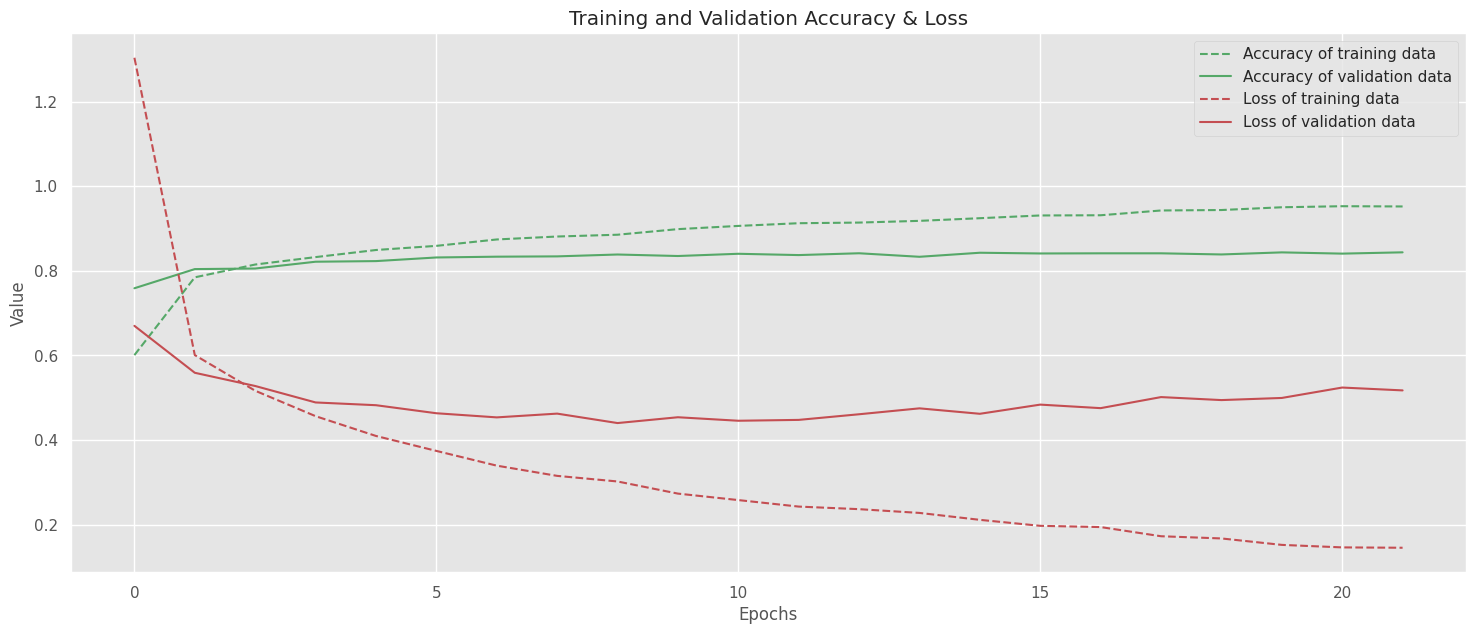

1273/1273 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      4623
           1       0.99      0.98      0.99     12964
           2       0.99      0.99      0.99      2305
           3       0.99      0.99      0.99      1742
           4       0.83      0.82      0.82      3818
           5       0.95      0.97      0.96     15283

    accuracy                           0.94     40735
   macro avg       0.93      0.93      0.93     40735
weighted avg       0.94      0.94      0.94     40735



In [37]:
def plot(model):
    plt.figure(figsize=(18, 7))
    # Plot accuracy and loss
    plt.plot(model.history['accuracy'], 'g--', label='Accuracy of training data')
    plt.plot(model.history['val_accuracy'], 'g', label='Accuracy of validation data')
    plt.plot(model.history['loss'], 'r--', label='Loss of training data')
    plt.plot(model.history['val_loss'], 'r', label='Loss of validation data')
    plt.title('Training and Validation Accuracy & Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

plot(DNN)

# Print confusion matrix for training data
y_pred_train = model_dnn.predict(X_train_val)
# Take the class with the highest probability from the train predictions
max_y_pred_train = np.argmax(y_pred_train, axis=1)
max_train = np.argmax(y_train_res, axis=1)
print(classification_report(max_train, max_y_pred_train))


In [38]:
score = model_dnn.evaluate(X_test_val, y_test_val, verbose=1)

print('\nAccuracy on test data: %0.2f' % score[1])
print('\nLoss on test data: %0.2f' % score[0])

425/425 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8397 - loss: 0.5272

Accuracy on test data: 0.84

Loss on test data: 0.54


In [39]:
def confusion_matrix(y, y_pred):
    labels=['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']
    matrix = metrics.confusion_matrix(y, y_pred)
    plt.figure(figsize=(9, 6))
    ax= sns.heatmap(matrix, cmap='coolwarm', linecolor='white', linewidths=1, xticklabels=labels, yticklabels=labels, annot=True, fmt='d')
    #bottom, top = ax.get_ylim()
    #ax.set_ylim(bottom + 0.5, top - 0.5)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step
              precision    recall  f1-score   support

           0       0.57      0.53      0.55      1541
           1       0.95      0.93      0.94      4322
           2       0.98      0.97      0.97       768
           3       0.97      0.96      0.96       581
           4       0.53      0.50      0.51      1273
           5       0.87      0.91      0.89      5094

    accuracy                           0.84     13579
   macro avg       0.81      0.80      0.81     13579
weighted avg       0.84      0.84      0.84     13579



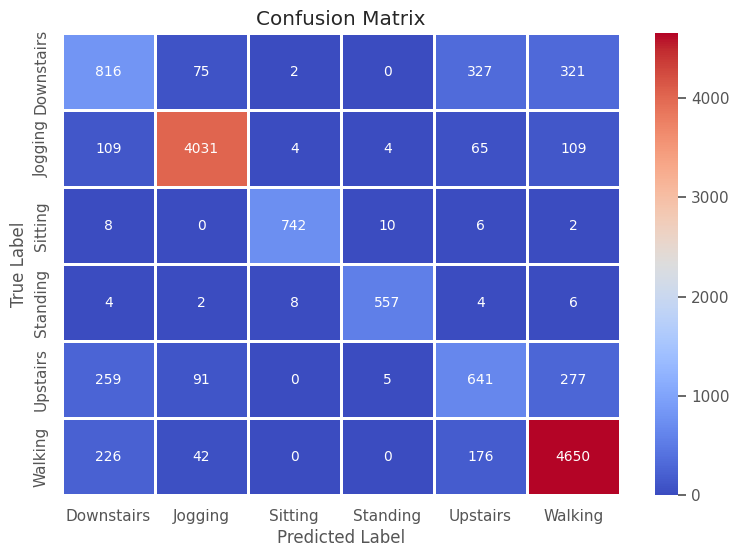

In [40]:
# Take the class with the highest probability from the test predictions
y_pred_test = model_dnn.predict(X_test_val)
max_y_pred_test = np.argmax(y_pred_test, axis = 1)
max_y_test = np.argmax(y_test_val, axis = 1)

#confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))
confusion_matrix(max_y_test, max_y_pred_test)

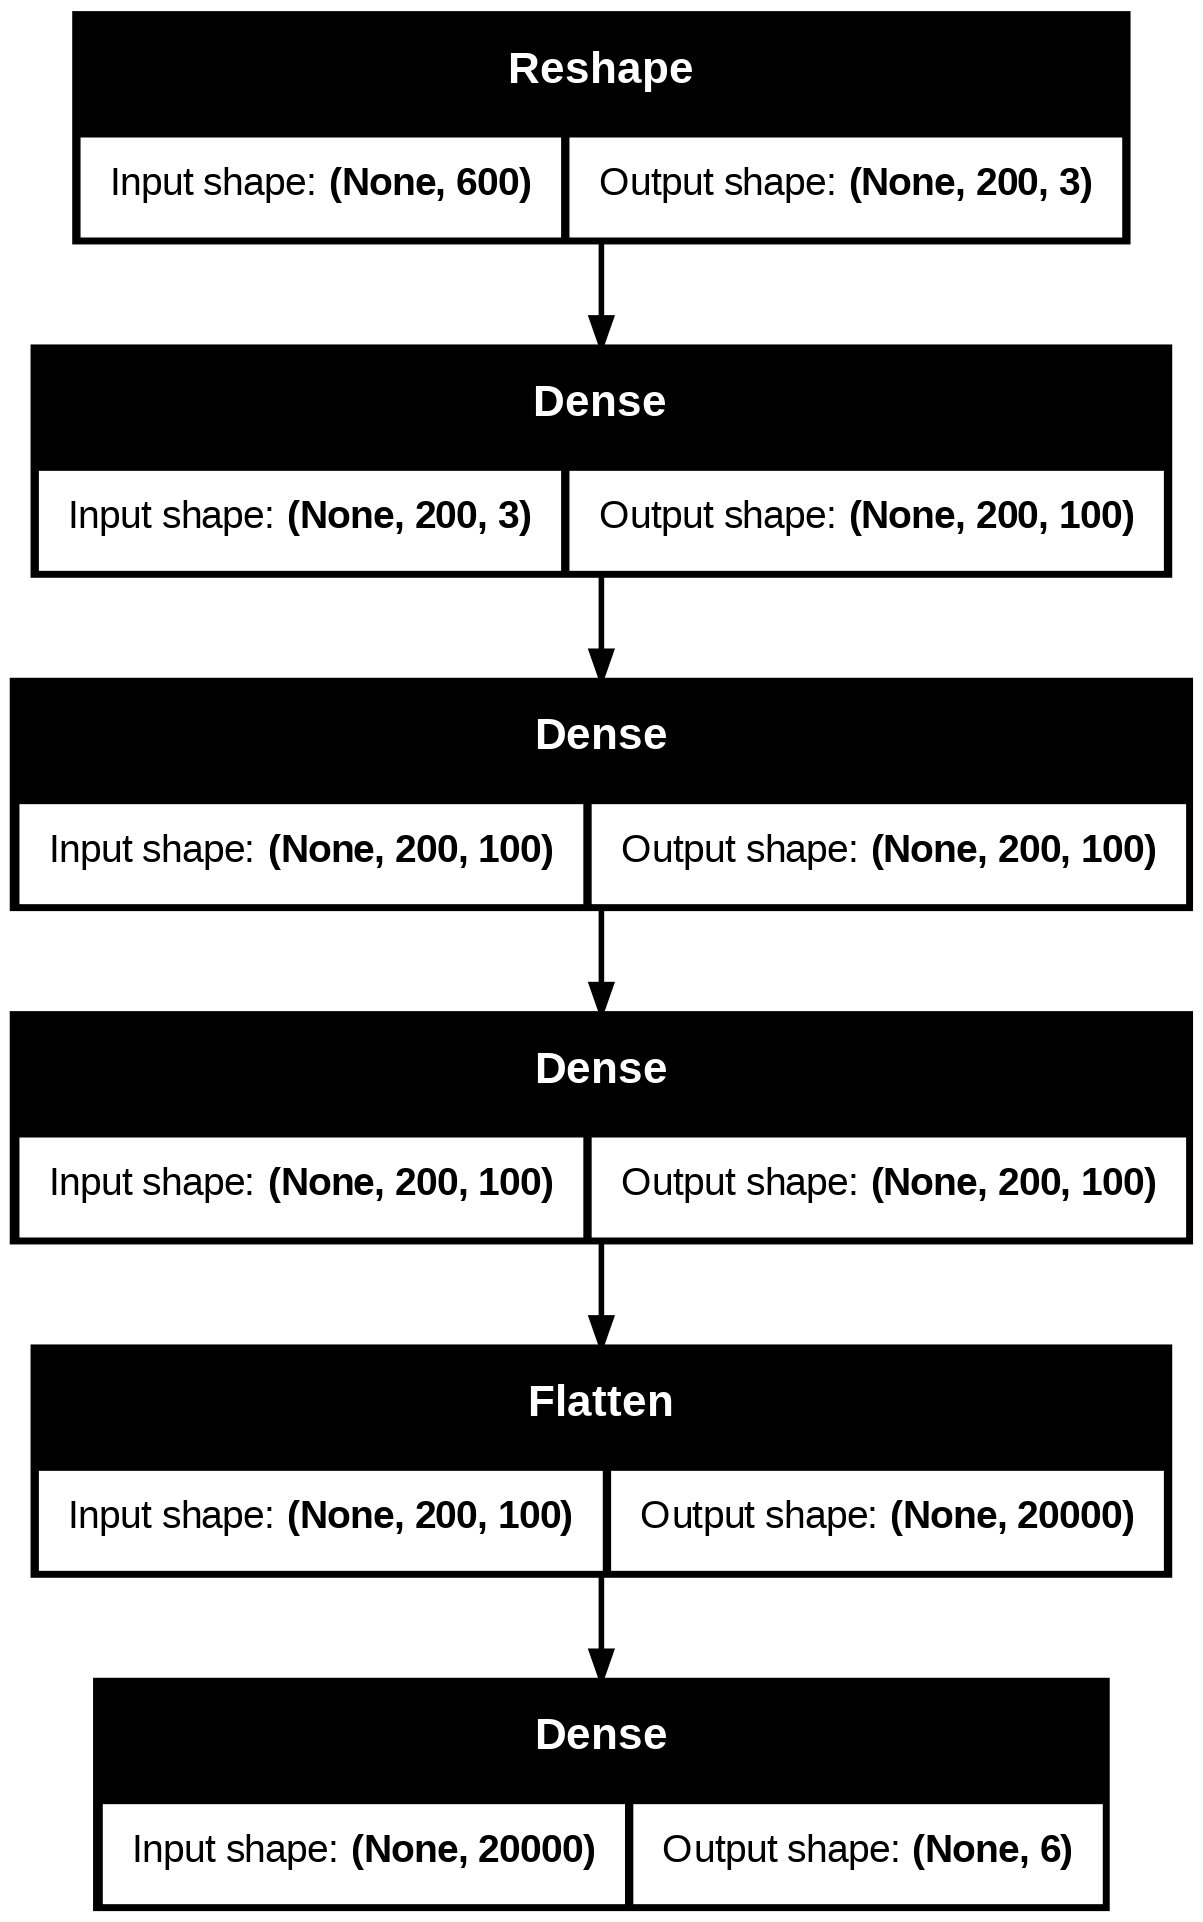

In [ ]:
from keras.utils import plot_model
plot_model(model_dnn, show_shapes=True, to_file='model_dnn_100.png')

# **DNN ( 3 dense layers, n_neurons/layer: 64)**

In [ ]:
model_dnn_64 = make_bare_dnn_model(n_neurons = 64)
print(model_dnn_64.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)                  │ (None, 200, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 200, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 200, 64)             │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 200, 64)             │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │          76,806 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 85,382 (333.52 KB)

 Trainable params: 85,382 (333.52 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
DNN_64 = model_dnn_64.fit(X_train_val,
                      y_train_val,
                      batch_size=batch_size,
                      epochs=epochs,
                      callbacks=callbacks_list,
                      validation_split=0.2,
                      verbose=1)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 805ms/step - accuracy: 0.8866 - loss: 0.3089 - val_accuracy: 0.8340 - val_loss: 0.4536
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 724ms/step - accuracy: 0.8915 - loss: 0.2958 - val_accuracy: 0.8305 - val_loss: 0.4564


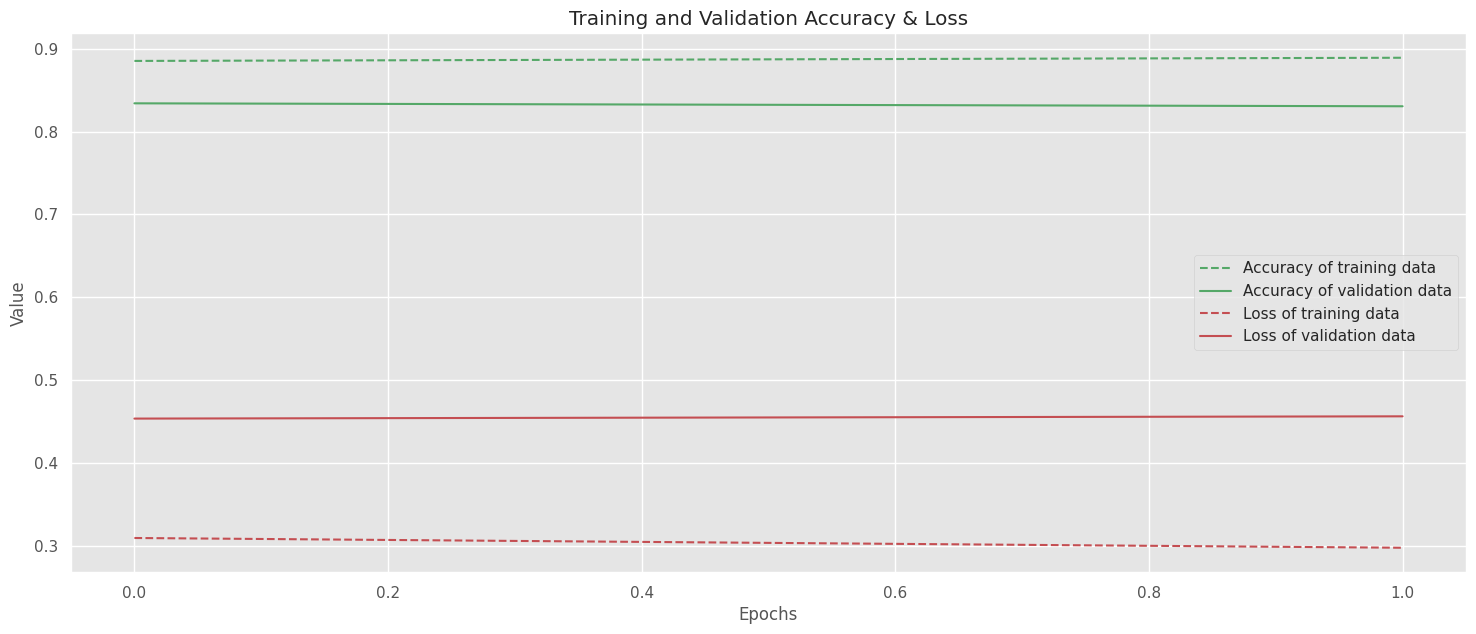

1273/1273 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step
              precision    recall  f1-score   support

           0       0.78      0.53      0.63      4623
           1       0.96      0.98      0.97     12964
           2       0.97      0.95      0.96      2305
           3       0.93      0.95      0.94      1742
           4       0.61      0.74      0.67      3818
           5       0.90      0.93      0.91     15283

    accuracy                           0.88     40735
   macro avg       0.86      0.85      0.85     40735
weighted avg       0.88      0.88      0.88     40735



In [ ]:
plot(DNN_64)

# Print confusion matrix for training data
y_pred_train = model_dnn_64.predict(X_train_val)
# Take the class with the highest probability from the train predictions
max_y_pred_train = np.argmax(y_pred_train, axis=1)
max_train = np.argmax(y_train_res, axis=1)
print(classification_report(max_train, max_y_pred_train))

In [ ]:
score = model_dnn_64.evaluate(X_test_val, y_test_val, verbose=1)

print('\nAccuracy on test data: %0.2f' % score[1])
print('\nLoss on test data: %0.2f' % score[0])

425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8292 - loss: 0.4593

Accuracy on test data: 0.83

Loss on test data: 0.46


425/425 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
              precision    recall  f1-score   support

           0       0.62      0.37      0.46      1541
           1       0.94      0.96      0.95      4322
           2       0.97      0.95      0.96       768
           3       0.93      0.94      0.94       581
           4       0.47      0.56      0.52      1273
           5       0.85      0.89      0.87      5094

    accuracy                           0.83     13579
   macro avg       0.80      0.78      0.78     13579
weighted avg       0.83      0.83      0.82     13579



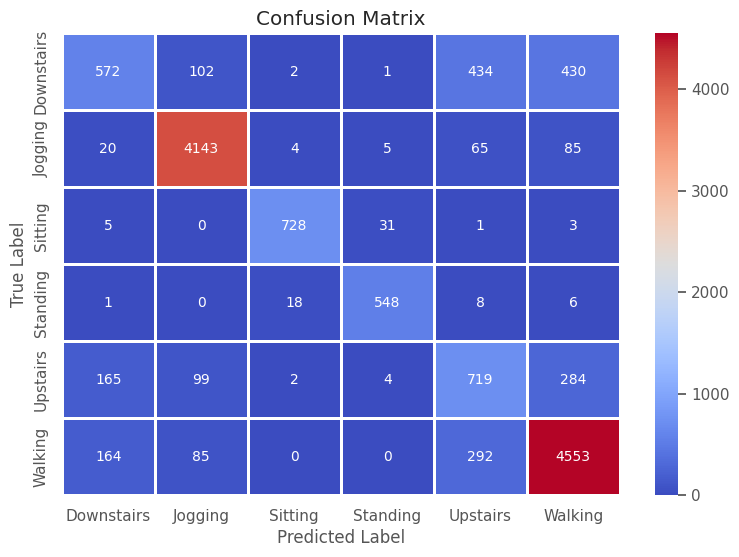

In [ ]:
# Take the class with the highest probability from the test predictions
y_pred_test = model_dnn_64.predict(X_test_val)
max_y_pred_test = np.argmax(y_pred_test, axis = 1)
max_y_test = np.argmax(y_test_val, axis = 1)

#confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))
confusion_matrix(max_y_test, max_y_pred_test)

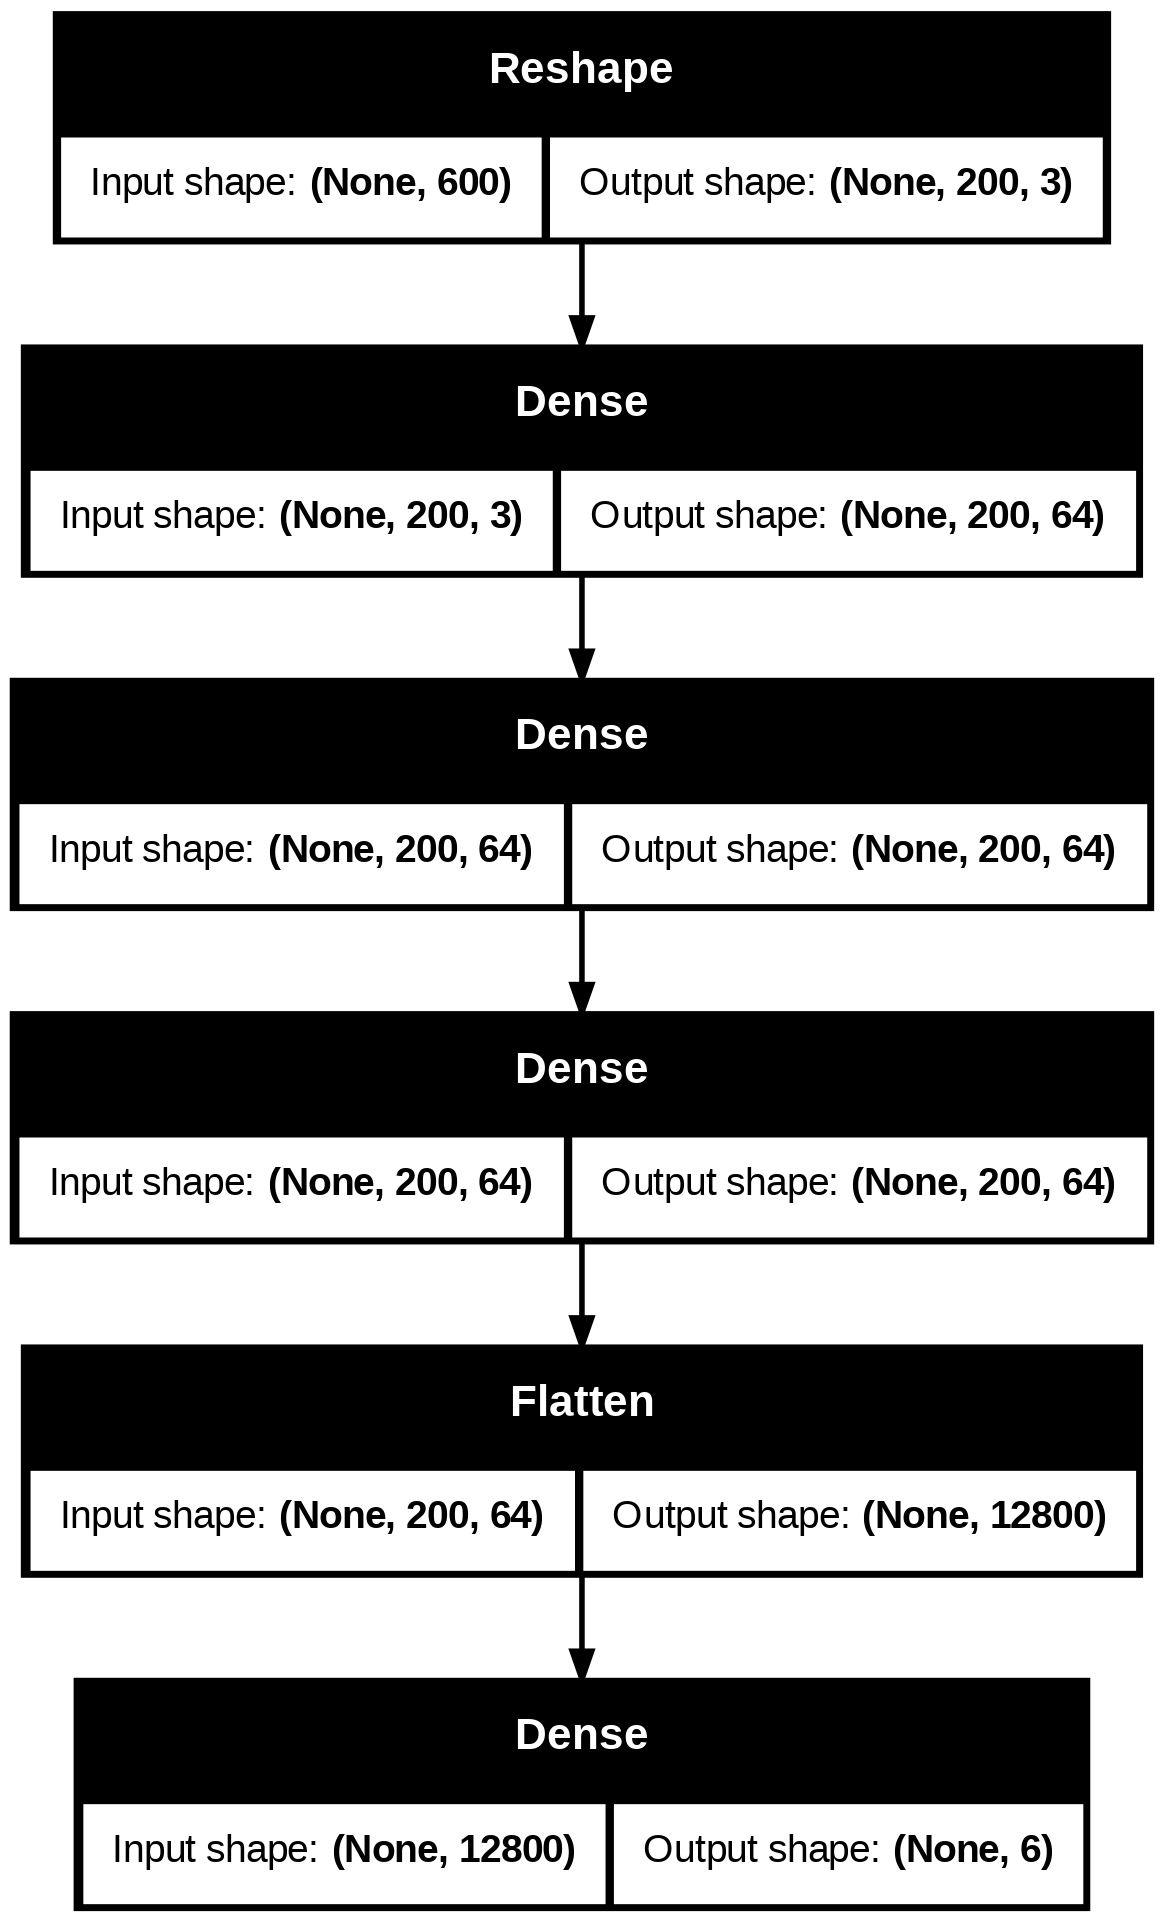

In [ ]:
from keras.utils import plot_model
plot_model(model_dnn_64, show_shapes=True, to_file='model_dnn_64.png')

___
## LSTM + Dense
___

In [26]:
def make_lstm_dense_model(lstm_neurons, dense_neurons, drop_out):
  model = Sequential()
  model.add(Reshape((time_steps, 3), input_shape=(input_shape,)))
  model.add(LSTM(lstm_neurons, input_shape=(input_shape,)))
  model.add(Dropout(drop_out))
  model.add(Dense(dense_neurons, activation='relu'))
  model.add(Dense(num_classes, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

In [27]:
model_lstm_dense_100 = make_lstm_dense_model(lstm_neurons= 100, dense_neurons= 100, drop_out= 0.5)
print(model_lstm_dense_100.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 200, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100)                 │          41,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             606 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,306 (204.32 KB)

 Trainable params: 52,306 (204.32 KB)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
batch_size = 1024
epochs = 50

lstm_dense_100 = model_lstm_dense_100.fit(X_train_val, y_train_val, batch_size=batch_size,
                      epochs=epochs, callbacks=callbacks_list, validation_split=0.2,verbose=1)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.3485 - loss: 1.5781 - val_accuracy: 0.6261 - val_loss: 1.0147
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.6421 - loss: 0.9498 - val_accuracy: 0.7641 - val_loss: 0.6830
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7606 - loss: 0.7001 - val_accuracy: 0.7899 - val_loss: 0.5851
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7887 - loss: 0.6087 - val_accuracy: 0.8023 - val_loss: 0.5670
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7965 - loss: 0.5915 - val_accuracy: 0.8127 - val_loss: 0.5454
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8064 - loss: 0.5669 - val_accuracy: 0.8285 - val_loss: 0.4931
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8223 - loss: 0.5173 - val_accuracy: 0.8380 - val_loss: 0.4570
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8362 - loss: 0.4688 - val_accuracy: 0.8398 - val_loss:

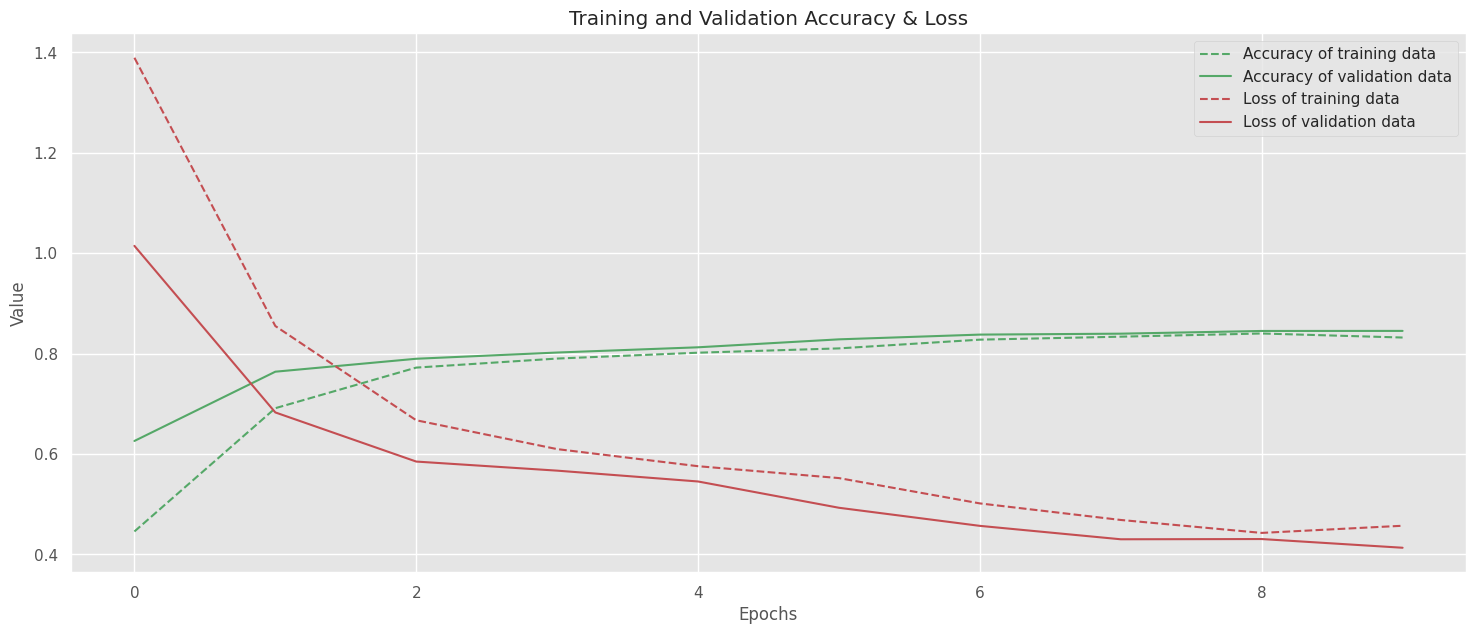

1273/1273 ━━━━━━━━━━━━━━━━━━━━ 91s 72ms/step
              precision    recall  f1-score   support

           0       0.57      0.48      0.52      4623
           1       0.97      0.94      0.95     12964
           2       0.97      0.85      0.91      2305
           3       0.84      0.96      0.90      1742
           4       0.50      0.41      0.45      3818
           5       0.86      0.97      0.92     15283

    accuracy                           0.85     40735
   macro avg       0.79      0.77      0.77     40735
weighted avg       0.84      0.85      0.84     40735



In [41]:
plot(lstm_dense_100)

# Print confusion matrix for training data
y_pred_train = model_lstm_dense_100.predict(X_train_val)
# Take the class with the highest probability from the train predictions
max_y_pred_train = np.argmax(y_pred_train, axis=1)
max_train = np.argmax(y_train_res, axis=1)
print(classification_report(max_train, max_y_pred_train))

In [42]:
score = model_lstm_dense_100.evaluate(X_test_val, y_test_val, verbose=1)

print('\nAccuracy on test data: %0.2f' % score[1])
print('\nLoss on test data: %0.2f' % score[0])

425/425 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.8408 - loss: 0.4301

Accuracy on test data: 0.84

Loss on test data: 0.43


425/425 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step
              precision    recall  f1-score   support

           0       0.56      0.49      0.52      1541
           1       0.97      0.92      0.95      4322
           2       0.97      0.86      0.91       768
           3       0.84      0.96      0.90       581
           4       0.48      0.39      0.43      1273
           5       0.86      0.97      0.91      5094

    accuracy                           0.84     13579
   macro avg       0.78      0.76      0.77     13579
weighted avg       0.83      0.84      0.83     13579



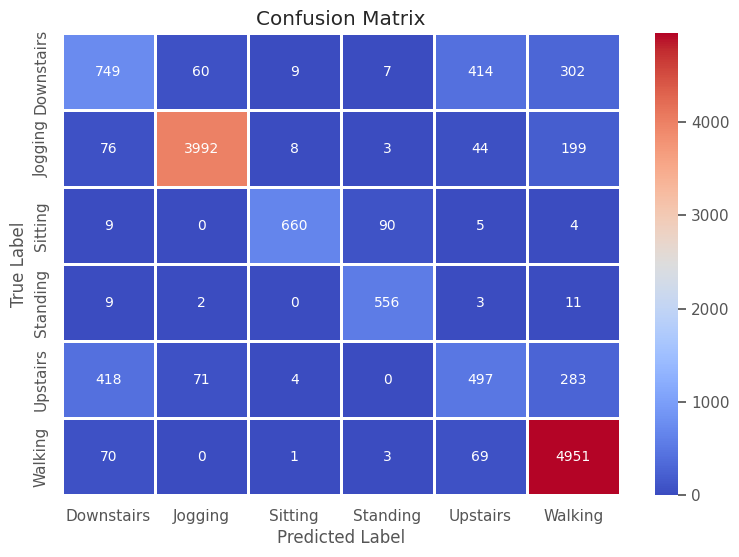

In [43]:
# Take the class with the highest probability from the test predictions
y_pred_test = model_lstm_dense_100.predict(X_test_val)
max_y_pred_test = np.argmax(y_pred_test, axis = 1)
max_y_test = np.argmax(y_test_val, axis = 1)

#confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))
confusion_matrix(max_y_test, max_y_pred_test)


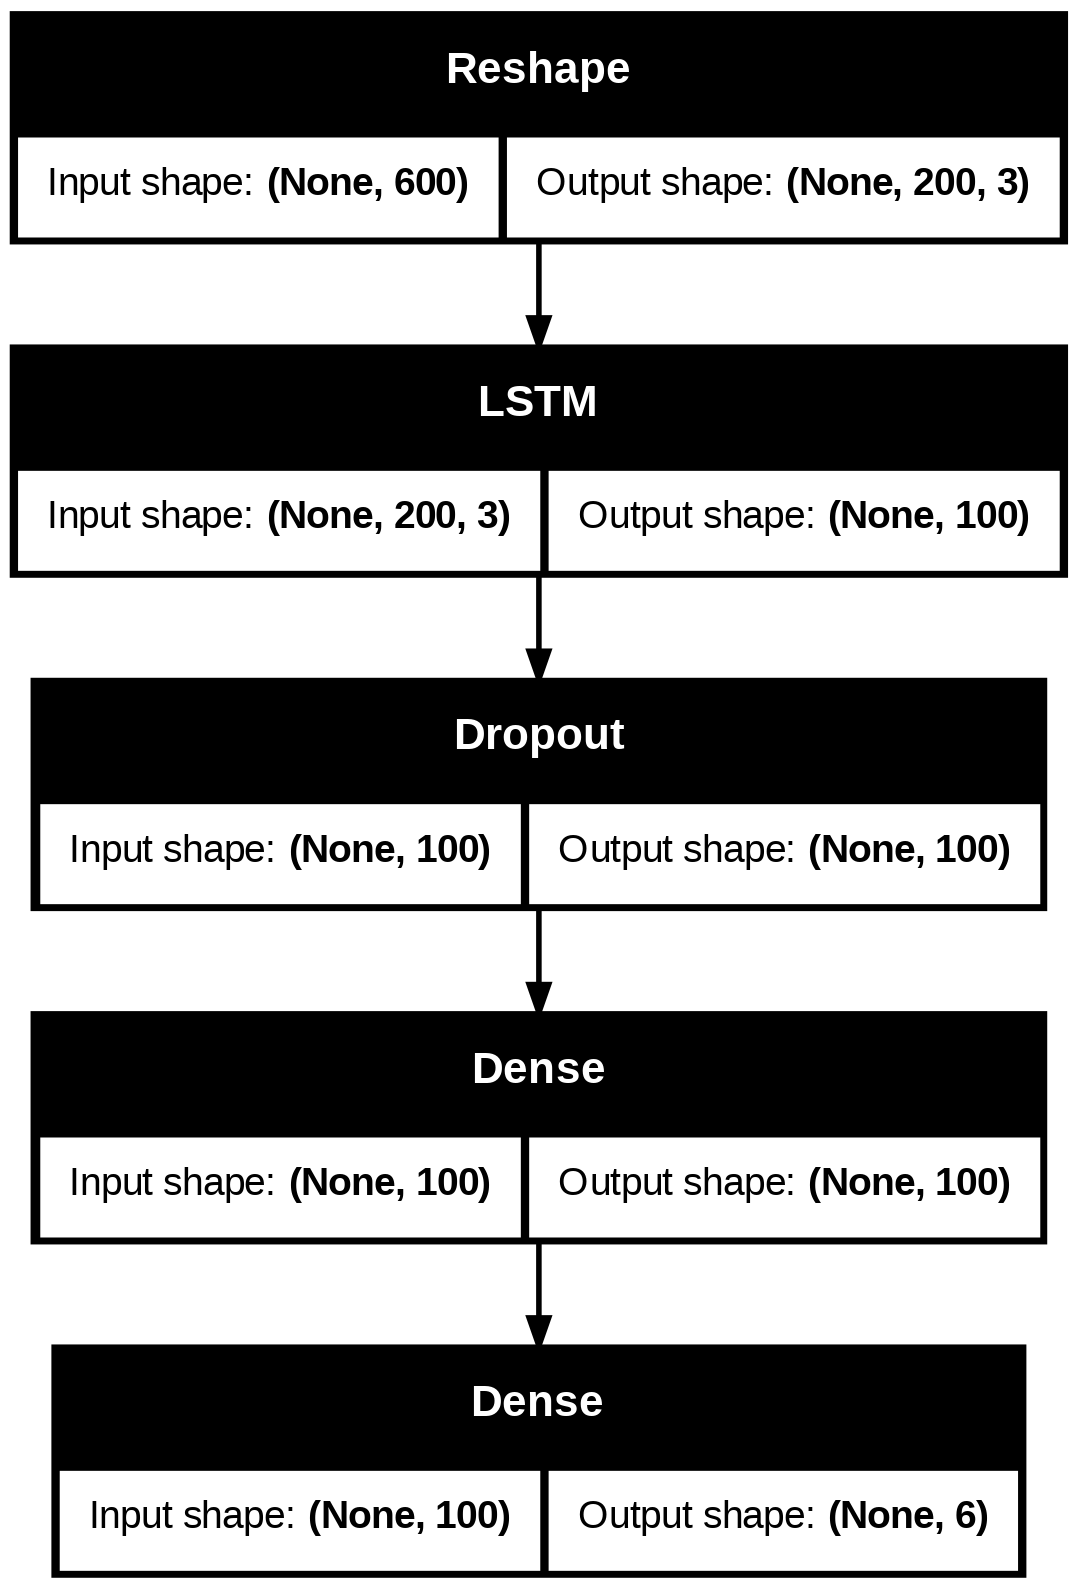

In [45]:
from keras.utils import plot_model
plot_model(model_lstm_dense_100, show_shapes=True, to_file='model_lstm_dense_100.png')

___
#### LSTM:64 + Dropout: 0.5 + Dense: 64
___

In [44]:
model_lstm_dense_64 = make_lstm_dense_model(lstm_neurons= 64, dense_neurons= 64, drop_out= 0.5)
print(model_lstm_dense_64.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)                  │ (None, 200, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,958 (85.77 KB)

 Trainable params: 21,958 (85.77 KB)

 Non-trainable params: 0 (0.00 B)

None


In [46]:
lstm_dense_64 = model_lstm_dense_64.fit(X_train_val, y_train_val, batch_size=batch_size,
                      epochs=epochs, callbacks=callbacks_list, validation_split=0.2,verbose=1)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.3667 - loss: 1.6015 - val_accuracy: 0.5968 - val_loss: 1.0957
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5930 - loss: 1.0499 - val_accuracy: 0.7415 - val_loss: 0.7068
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7200 - loss: 0.8414 - val_accuracy: 0.7695 - val_loss: 0.6634
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7580 - loss: 0.6966 - val_accuracy: 0.7967 - val_loss: 0.5953
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7904 - loss: 0.6254 - val_accuracy: 0.7991 - val_loss: 0.5764
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7970 - loss: 0.5967 - val_accuracy: 0.8074 - val_loss: 0.5387
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7981 - loss: 0.5741 - val_accuracy: 0.8102 - val_loss: 0.5317
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8132 - loss: 0.5475 - val_accuracy: 0.8186 - val_loss:

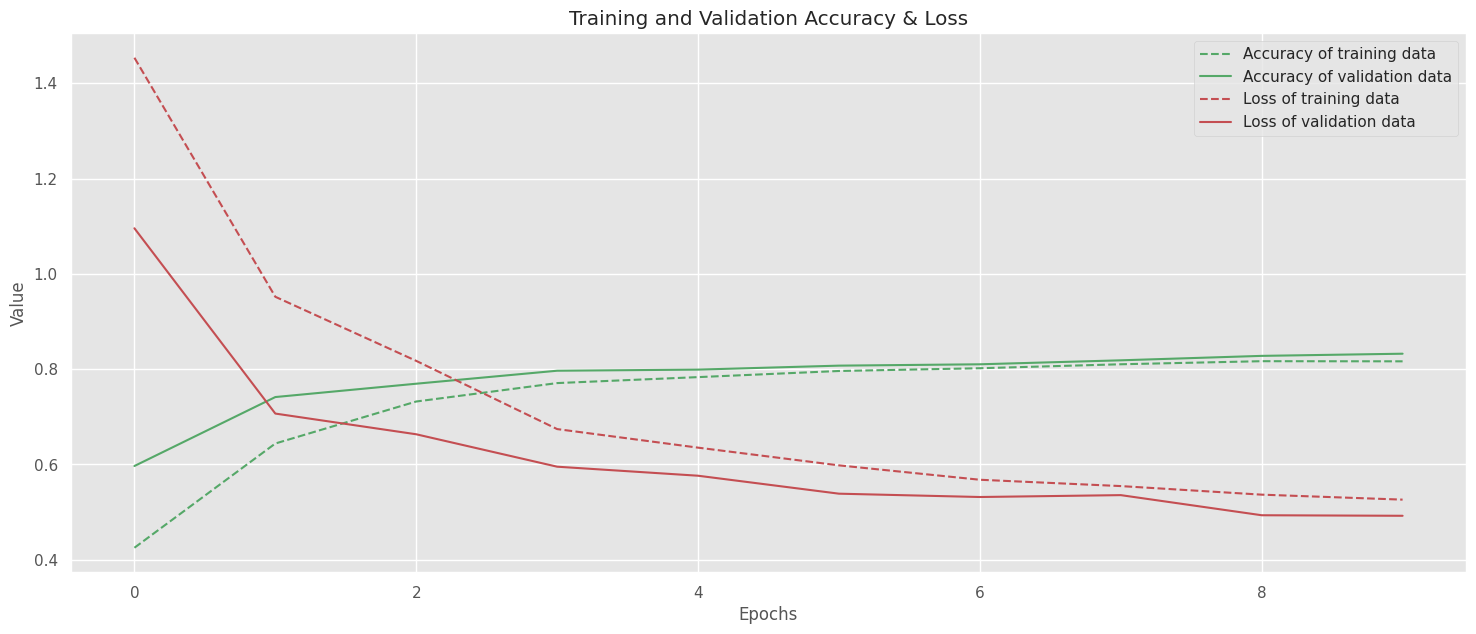

1273/1273 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step
              precision    recall  f1-score   support

           0       0.69      0.33      0.45      4623
           1       0.93      0.96      0.95     12964
           2       0.97      0.85      0.91      2305
           3       0.85      0.95      0.90      1742
           4       0.48      0.44      0.46      3818
           5       0.82      0.95      0.88     15283

    accuracy                           0.83     40735
   macro avg       0.79      0.75      0.76     40735
weighted avg       0.82      0.83      0.82     40735



In [47]:
plot(lstm_dense_64)

# Print confusion matrix for training data
y_pred_train = model_lstm_dense_64.predict(X_train_val)
# Take the class with the highest probability from the train predictions
max_y_pred_train = np.argmax(y_pred_train, axis=1)
max_train = np.argmax(y_train_res, axis=1)
print(classification_report(max_train, max_y_pred_train))

In [48]:
score = model_lstm_dense_64.evaluate(X_test_val, y_test_val, verbose=1)

print('\nAccuracy on test data: %0.2f' % score[1])
print('\nLoss on test data: %0.2f' % score[0])

425/425 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8277 - loss: 0.4992

Accuracy on test data: 0.83

Loss on test data: 0.50


425/425 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step
              precision    recall  f1-score   support

           0       0.67      0.34      0.45      1541
           1       0.93      0.96      0.94      4322
           2       0.97      0.86      0.91       768
           3       0.85      0.94      0.89       581
           4       0.45      0.42      0.43      1273
           5       0.82      0.95      0.88      5094

    accuracy                           0.83     13579
   macro avg       0.78      0.74      0.75     13579
weighted avg       0.81      0.83      0.81     13579



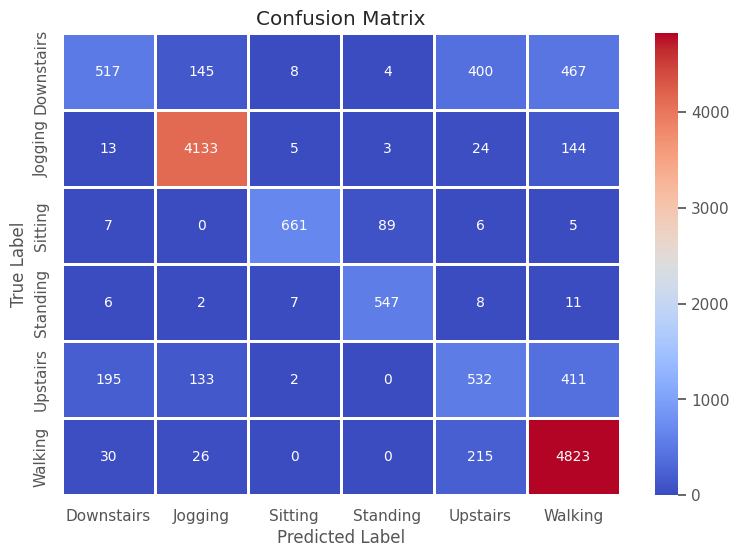

In [49]:
# Take the class with the highest probability from the test predictions
y_pred_test = model_lstm_dense_64.predict(X_test_val)
max_y_pred_test = np.argmax(y_pred_test, axis = 1)
max_y_test = np.argmax(y_test_val, axis = 1)

#confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))
confusion_matrix(max_y_test, max_y_pred_test)

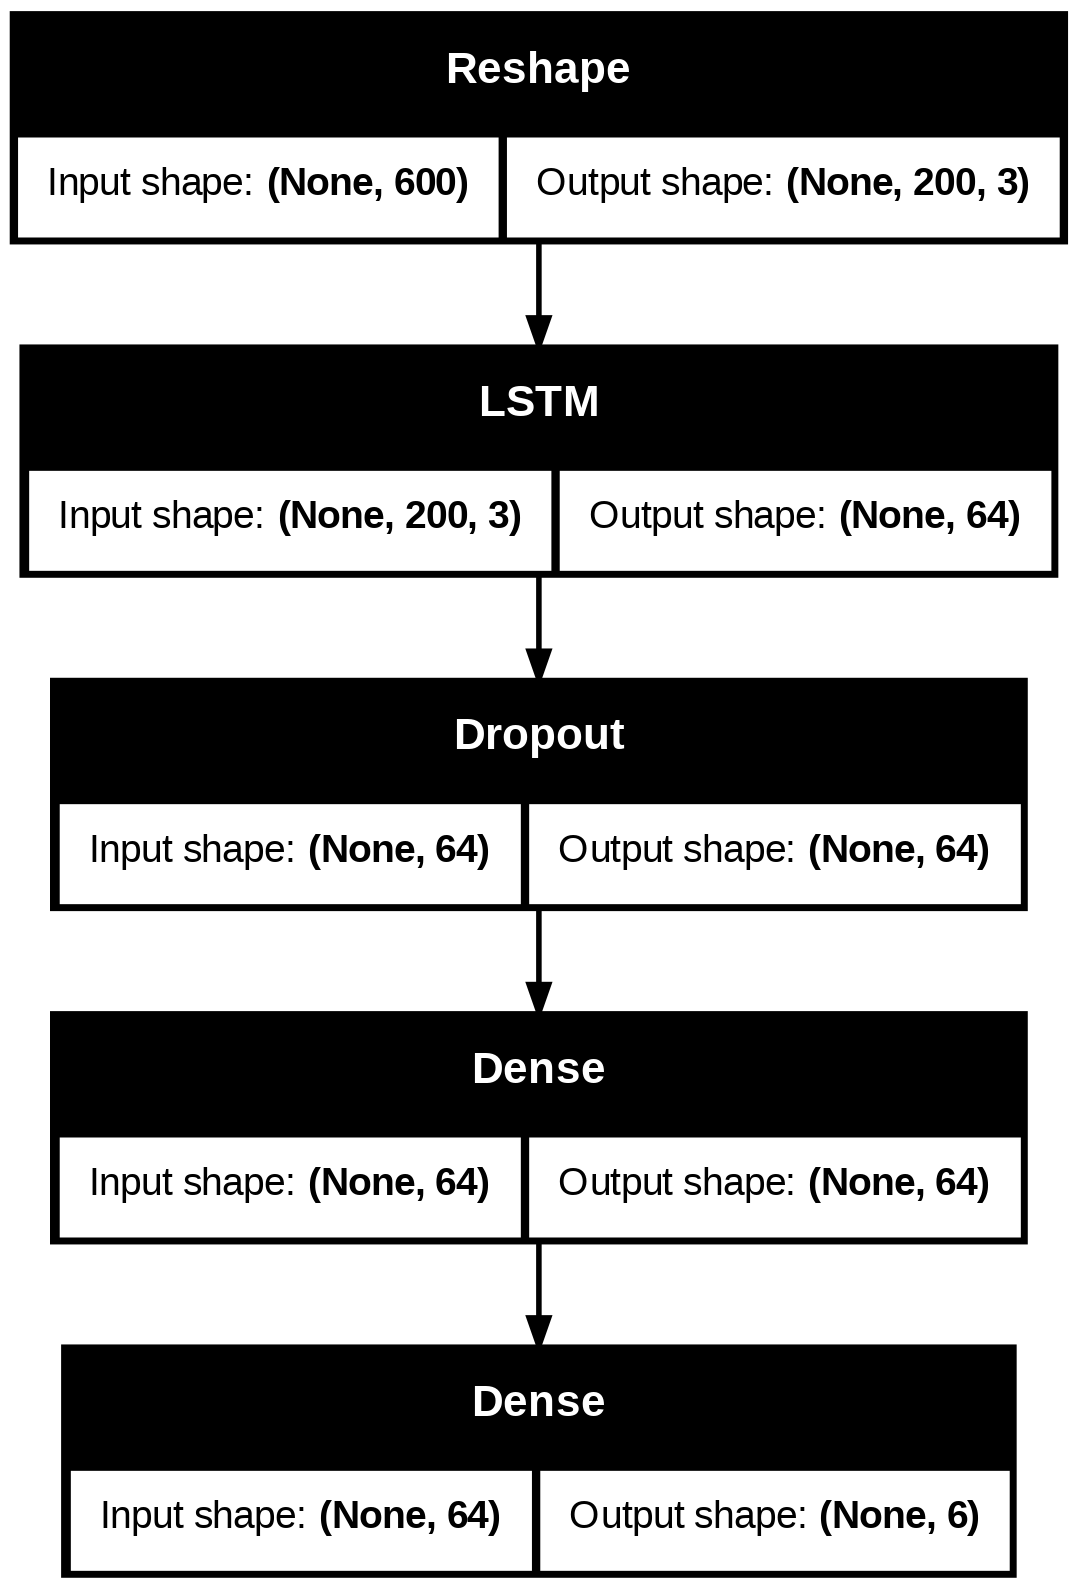

In [50]:
plot_model(model_lstm_dense_64, show_shapes=True, to_file='model_lstm_dense_64.png')

___
### 3.2.4 CNN-LSTM and ConvLSTM


In [52]:
def make_cnn_lstm_model(lstm_neurons,dense_neurons,drop_out):
  model = Sequential()
  model.add(TimeDistributed(Conv1D(filters=64, kernel_size=3, activation='relu'),
                            input_shape=(None,n_length,n_features)))
  model.add(TimeDistributed(Conv1D(filters=64, kernel_size=3, activation='relu')))
  model.add(TimeDistributed(Dropout(drop_out)))
  model.add(TimeDistributed(MaxPooling1D(pool_size=2)))
  model.add(TimeDistributed(Flatten()))
  model.add(LSTM(lstm_neurons))
  model.add(Dropout(drop_out))
  model.add(Dense(dense_neurons, activation='relu'))
  model.add(Dense(num_classes, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

In [56]:
# reshape data into time steps of sub-sequences
n_steps, n_length = 20, 10
X_train_cnn = X_train_res.reshape((X_train_res.shape[0], n_steps, n_length, n_features))
X_test_cnn = X_test_res.reshape((X_test_res.shape[0], n_steps, n_length, n_features))

In [57]:
model_cnn_lstm = make_cnn_lstm_model(lstm_neurons= 100, dense_neurons = 100, drop_out = 0.5)
print(model_cnn_lstm.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, None, 8, 64)         │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, None, 6, 64)         │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, None, 6, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, None, 3, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, None, 192)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100)                 │         117,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 6)                   │             606 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140,898 (550.38 KB)

 Trainable params: 140,898 (550.38 KB)

 Non-trainable params: 0 (0.00 B)

None


In [58]:
batch_size = 1024
epochs = 50
cnn_lstm = model_cnn_lstm.fit(X_train_cnn, y_train_val, batch_size=batch_size,
                      epochs=epochs, callbacks=callbacks_list, validation_split=0.2,verbose=1)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.4442 - loss: 1.3807 - val_accuracy: 0.7922 - val_loss: 0.6041
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.7876 - loss: 0.6086 - val_accuracy: 0.8401 - val_loss: 0.4384
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.8313 - loss: 0.4673 - val_accuracy: 0.8667 - val_loss: 0.3694
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.8504 - loss: 0.4090 - val_accuracy: 0.8747 - val_loss: 0.3427
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.8704 - loss: 0.3593 - val_accuracy: 0.8889 - val_loss: 0.2950
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.8890 - loss: 0.3252 - val_accuracy: 0.8829 - val_loss: 0.3101
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9012 - loss: 0.2859 - val_accuracy: 0.9194 - val_loss: 0.2352
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 93s 3s/step - accuracy: 0.9181 - loss: 0.2459 - val_accuracy: 0.9284 - val_

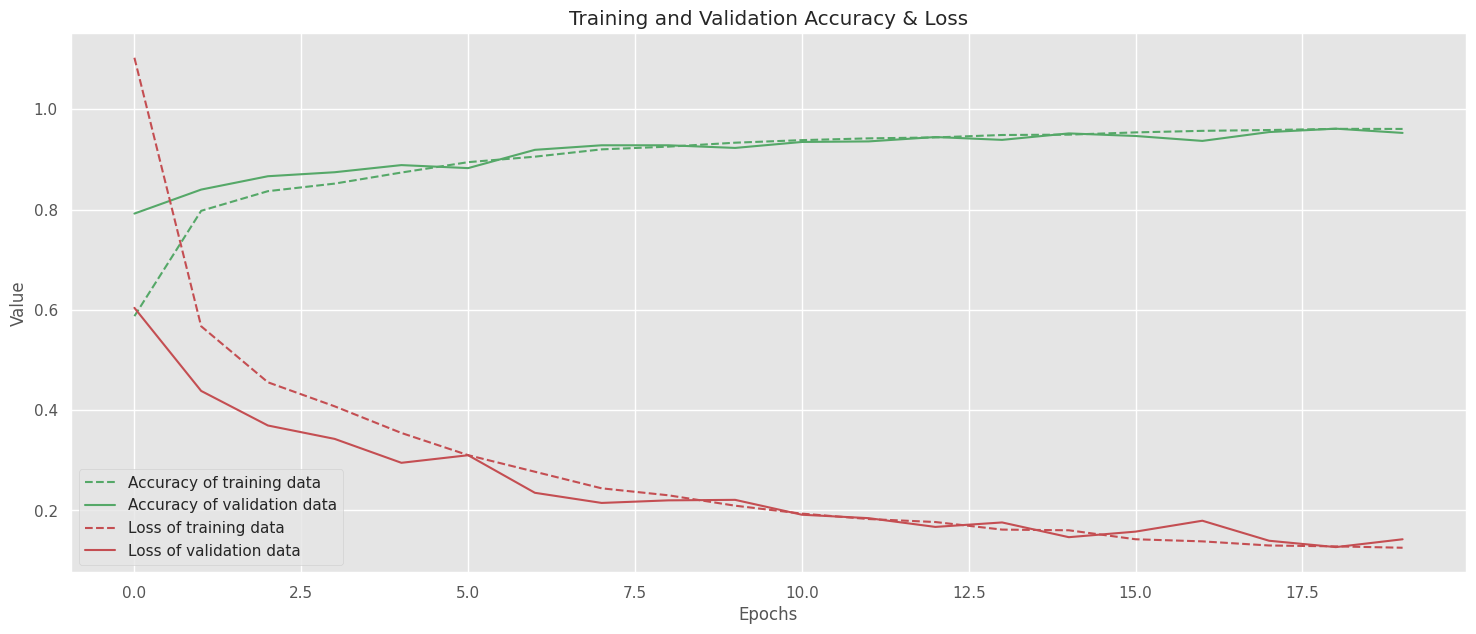

40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 568ms/step
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4623
           1       1.00      0.98      0.99     12964
           2       0.98      0.97      0.98      2305
           3       0.97      0.96      0.97      1742
           4       0.91      0.77      0.84      3818
           5       0.99      1.00      0.99     15283

    accuracy                           0.96     40735
   macro avg       0.94      0.94      0.94     40735
weighted avg       0.96      0.96      0.96     40735



In [59]:
plot(cnn_lstm)

# Print confusion matrix for training data
y_pred_train = model_cnn_lstm.predict(X_train_cnn, batch_size=batch_size)
# Take the class with the highest probability from the train predictions
max_y_pred_train = np.argmax(y_pred_train, axis=1)
max_train = np.argmax(y_train_res, axis=1)
print(classification_report(max_train, max_y_pred_train))

In [60]:
score = model_cnn_lstm.evaluate(X_test_cnn, y_test_res, verbose=1, batch_size=batch_size)

print('\nAccuracy on test data: %0.2f' % score[1])
print('\nLoss on test data: %0.2f' % score[0])

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 275ms/step - accuracy: 0.9508 - loss: 0.1410

Accuracy on test data: 0.95

Loss on test data: 0.14


14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 350ms/step
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      1541
           1       1.00      0.97      0.98      4322
           2       0.97      0.96      0.96       768
           3       0.96      0.95      0.95       581
           4       0.89      0.74      0.80      1273
           5       0.98      1.00      0.99      5094

    accuracy                           0.95     13579
   macro avg       0.93      0.92      0.93     13579
weighted avg       0.95      0.95      0.95     13579



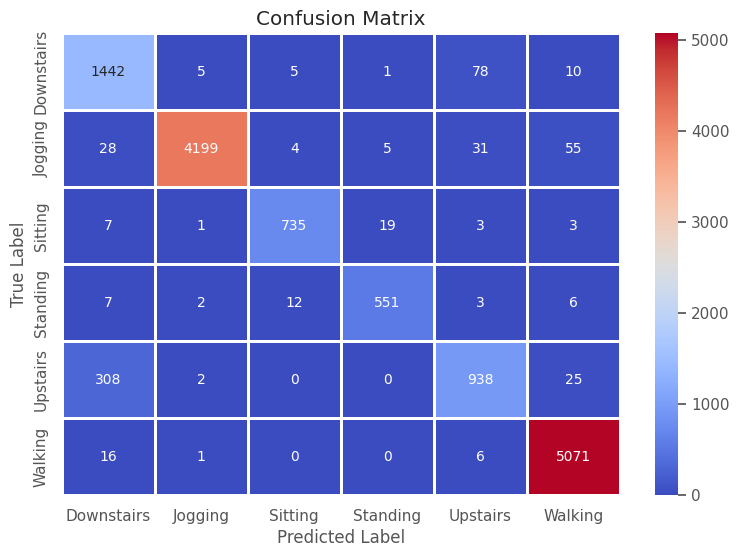

In [61]:
# Take the class with the highest probability from the test predictions
y_pred_test = model_cnn_lstm.predict(X_test_cnn, batch_size=batch_size)
max_y_pred_test = np.argmax(y_pred_test, axis = 1)
max_y_test = np.argmax(y_test_res, axis = 1)

#confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))
confusion_matrix(max_y_test, max_y_pred_test)

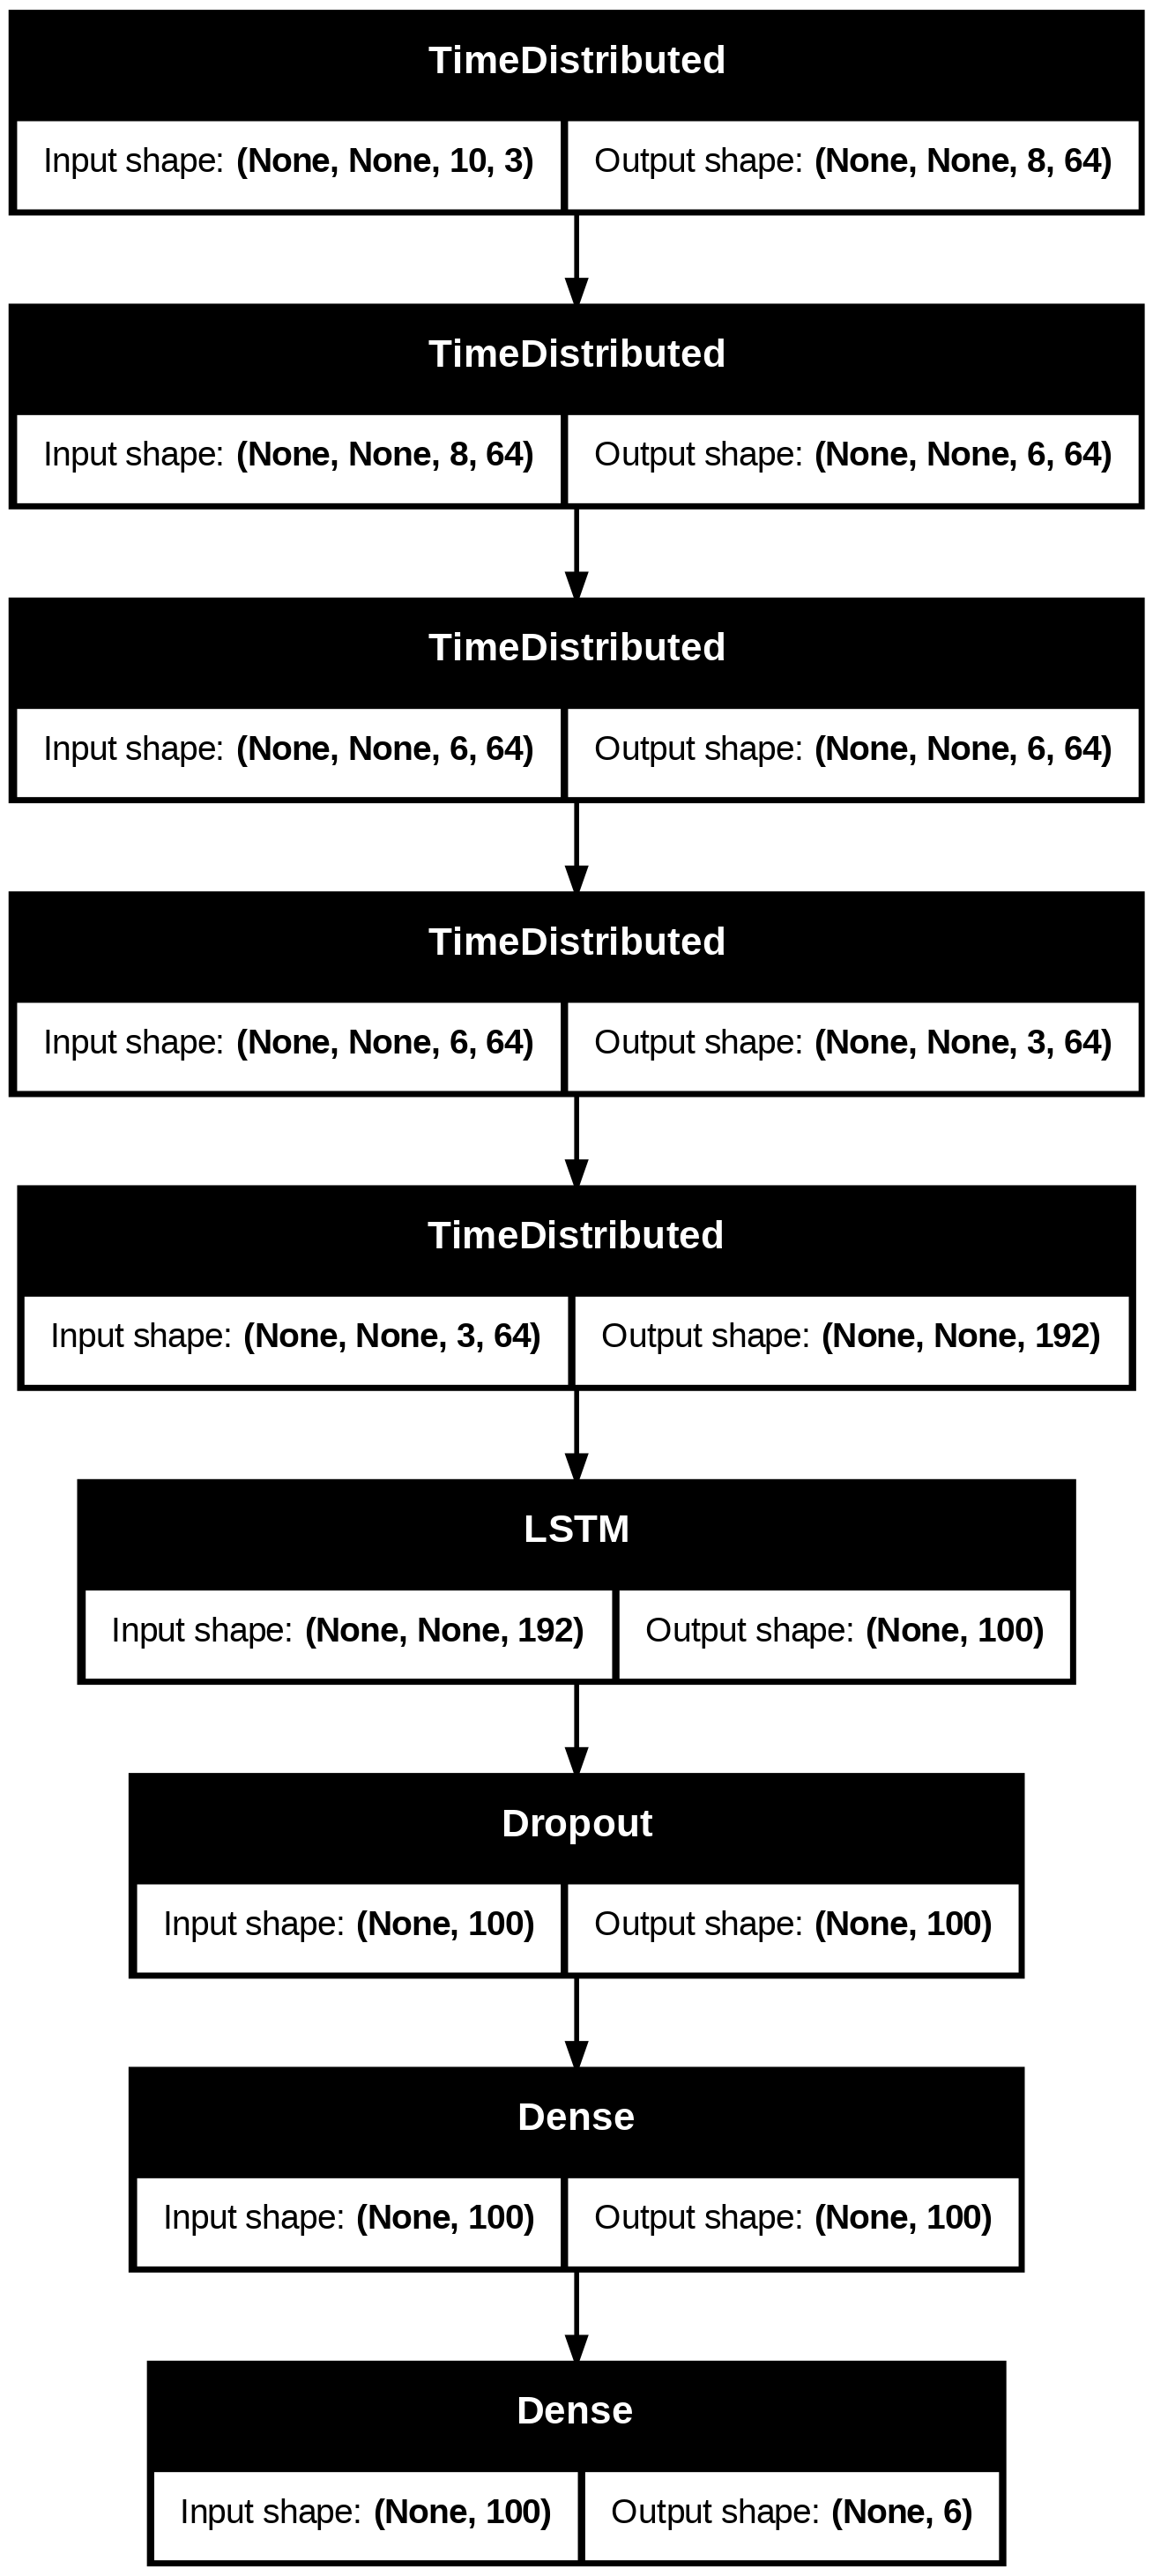

In [62]:
from keras.utils import plot_model
plot_model(model_cnn_lstm, show_shapes=True, to_file='model_cnn_lstm.png')